<div style="border: 3px solid #27548A; border-radius: 8px; padding: 30px 40px; background-color: #fefefe;">
    <h1 style="color: #27548A; font-size: 36px; font-weight: bold; text-align: center;">Startup Success Analysis</h1>
    <h3 style="color: #555; text-align: center; font-weight: normal;">A Data Driven Look at Startup Performance and Growth</h3>
    <hr style="border: 1px solid #ddd; margin: 20px 0;">
    <div style="font-size: 15px; line-height: 2.0; color: #333;">
        <b style="color: #27548A;">📋 Analysis Flow:</b><br>
        &nbsp;&nbsp;&nbsp;&nbsp;① Importing Libraries &nbsp;|&nbsp;
        ② Data Loading &nbsp;|&nbsp;
        ③ Data Cleaning &nbsp;|&nbsp;
        ④ Feature Engineering &nbsp;|&nbsp;
        ⑤ Exploratory Data Analysis &nbsp;
</div>

<hr style="border: 3px solid #4f4f4f;">
<div style="padding: 18px 24px; background-color: #27548A; border-radius: 6px;">
    <h2 style="color: #fff; margin: 0;">1 — Importing Libraries</h2>
</div>

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

plt.rcParams.update({
    'figure.figsize': (10, 5)
})
# white background and grid lines
sns.set_style('whitegrid')



<hr style="border: 3px solid #4f4f4f;">
<div style="padding: 18px 24px; background-color: #1278ba; border-radius: 6px;">
    <h2 style="color: #fff; margin: 0;">2 — Data Loading & Initial Inspection</h2>
</div>

In [26]:
# Load the dataset
df = pd.read_csv('startup_failure_prediction.csv')
#viewing cols
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Dataset shape: 5,000 rows × 15 columns
Columns: ['Startup_Name', 'Industry', 'Startup_Age', 'Funding_Amount', 'Number_of_Founders', 'Founder_Experience', 'Employees_Count', 'Revenue', 'Burn_Rate', 'Market_Size', 'Business_Model', 'Product_Uniqueness_Score', 'Customer_Retention_Rate', 'Marketing_Expense', 'Startup_Status']


In [27]:
# First 5 rows
df.head()

,Startup_Name,Industry,Startup_Age,Funding_Amount,Number_of_Founders,Founder_Experience,Employees_Count,Revenue,Burn_Rate,Market_Size,Business_Model,Product_Uniqueness_Score,Customer_Retention_Rate,Marketing_Expense,Startup_Status
0,Startup_1,Logistics,8,18328419,2,13,581,97866143,602731,Medium,B2B,2,79.61,987830,1
1,Startup_2,Education,3,39753708,3,16,529,36868744,820698,Large,B2C,3,32.47,599615,1
2,Startup_3,Healthcare,14,18073294,1,28,82,3478737,992205,Small,B2C,1,9.88,780730,1
3,Startup_4,E-commerce,5,19435653,4,14,234,80716899,536747,Medium,B2C,9,23.20,188588,1
4,Startup_5,Finance,14,4205797,4,17,960,53347246,555199,Medium,Hybrid,3,73.52,310892,1


In [28]:
# Data types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Startup_Name              5000 non-null   object 
 1   Industry                  5000 non-null   object 
 2   Startup_Age               5000 non-null   int64  
 3   Funding_Amount            5000 non-null   int64  
 4   Number_of_Founders        5000 non-null   int64  
 5   Founder_Experience        5000 non-null   int64  
 6   Employees_Count           5000 non-null   int64  
 7   Revenue                   5000 non-null   int64  
 8   Burn_Rate                 5000 non-null   int64  
 9   Market_Size               5000 non-null   object 
 10  Business_Model            5000 non-null   object 
 11  Product_Uniqueness_Score  5000 non-null   int64  
 12  Customer_Retention_Rate   5000 non-null   float64
 13  Marketing_Expense         5000 non-null   int64  
 14  Startup_

In [29]:
# Statistical summary of numeric cols
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Startup_Age,5000.0,6.99,4.35,0.00,3.00,7.00,11.00,14.00
Funding_Amount,5000.0,24973414.13,14457699.73,11209.00,12500121.50,24961046.00,37475316.50,49993132.00
Number_of_Founders,5000.0,2.50,1.12,1.00,2.00,2.00,4.00,4.00
Founder_Experience,5000.0,14.74,8.67,0.00,7.00,15.00,22.00,29.00
Employees_Count,5000.0,496.73,292.72,1.00,236.00,498.50,747.00,999.00
Revenue,5000.0,49920146.57,28789635.95,3213.00,24583074.75,50266757.00,74781643.75,99996630.00
Burn_Rate,5000.0,500959.92,287379.95,5016.00,249027.50,503405.50,751950.00,999554.00
Product_Uniqueness_Score,5000.0,4.96,2.58,1.00,3.00,5.00,7.00,9.00
Customer_Retention_Rate,5000.0,50.22,28.56,0.04,25.64,50.07,74.70,99.98
Marketing_Expense,5000.0,507304.29,289234.19,5253.00,259590.50,503504.50,760906.00,999866.00


In [30]:
# Distribution of categorical columns
cat_cols = ['Industry', 'Market_Size', 'Business_Model']
for col in cat_cols:
    print(f'\n── {col} ──')
    print(df[col].value_counts())


── Industry ──
Industry
AI/ML         743
Education     741
Tech          723
Healthcare    722
Logistics     721
E-commerce    678
Finance       672
Name: count, dtype: int64

── Market_Size ──
Market_Size
Large     1747
Small     1627
Medium    1626
Name: count, dtype: int64

── Business_Model ──
Business_Model
B2B       1690
Hybrid    1659
B2C       1651
Name: count, dtype: int64


<hr style="border: 3px solid #4f4f4f;">
<div style="padding: 18px 24px; background: linear-gradient(to right, #16C47F, #16ead1); border-radius: 6px;">
    <h2 style="color: #fff; margin: 0;">3 — Data Cleaning</h2>
</div>

<div style="padding: 10px; border-bottom: 4px solid #16C47F; background-color: #f0f0f0; border-radius: 4px;">
    <h3 style="margin: 0; color: #333;">3.1 — Missing Values</h3>
</div>

In [31]:
missing = df.isnull().sum()
print(' Missing values per column:')
if missing.any():
    print(missing[missing > 0])
    # Fill numeric columns with median, categorical with mode
    for col in df.select_dtypes(include='number').columns:
        df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include='object').columns:
        df[col].fillna(df[col].mode()[0], inplace=True)
    print('Missing values filled')
else:
    print('No missing values found')

 Missing values per column:
No missing values found


<div style="padding: 10px; border-bottom: 4px solid #16C47F; background-color: #f0f0f0; border-radius: 4px;">
    <h3 style="margin: 0; color: #333;">3.2 — Duplicate Rows</h3>
</div>

In [32]:
duplicates = df.duplicated().sum()
print(f' Duplicate rows: {duplicates}')
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Removed {duplicates} duplicate rows')
else:
    print('No duplicates found')

 Duplicate rows: 0
No duplicates found


<div style="padding: 10px; border-bottom: 4px solid #16C47F; background-color: #f0f0f0; border-radius: 4px;">
    <h3 style="margin: 0; color: #333;">3.3 — Data Type Validation</h3>
</div>

In [33]:
# Ensure numeric cols are actually numeric
numeric_expected = ['Funding_Amount', 'Revenue', 'Burn_Rate', 'Employees_Count',
                    'Marketing_Expense', 'Customer_Retention_Rate', 'Startup_Age',
                    'Founder_Experience', 'Number_of_Founders', 'Product_Uniqueness_Score']

for col in numeric_expected:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Data types validated')
print(df[numeric_expected].dtypes)

Data types validated
Funding_Amount                int64
Revenue                       int64
Burn_Rate                     int64
Employees_Count               int64
Marketing_Expense             int64
Customer_Retention_Rate     float64
Startup_Age                   int64
Founder_Experience            int64
Number_of_Founders            int64
Product_Uniqueness_Score      int64
dtype: object


<div style="padding: 10px; border-bottom: 4px solid #16C47F; background-color: #f0f0f0; border-radius: 4px;">
    <h3 style="margin: 0; color: #333;">3.4 — Outlier Detection (IQR Method)</h3>
</div>

In [34]:
# Check outliers on key financial columns — we keep them as they reflect real startup variability
financial_cols = ['Funding_Amount', 'Revenue', 'Burn_Rate', 'Employees_Count', 'Marketing_Expense']

print('Outlier check (IQR method):\n')
for col in financial_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 -1.5 * IQR, Q3 +1.5 *IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'  {col:<28} → {n_out:>4} outliers  |  range: [{lower:,.0f} – {upper:,.0f}]')

print('\nOutliers retained, they represent genuine startup variability, not data errors')

Outlier check (IQR method):

  Funding_Amount               →    0 outliers  |  range: [-24,962,671 – 74,938,109]
  Revenue                      →    0 outliers  |  range: [-50,714,779 – 150,079,497]
  Burn_Rate                    →    0 outliers  |  range: [-505,356 – 1,506,334]
  Employees_Count              →    0 outliers  |  range: [-530 – 1,514]
  Marketing_Expense            →    0 outliers  |  range: [-492,383 – 1,512,879]

Outliers retained, they represent genuine startup variability, not data errors


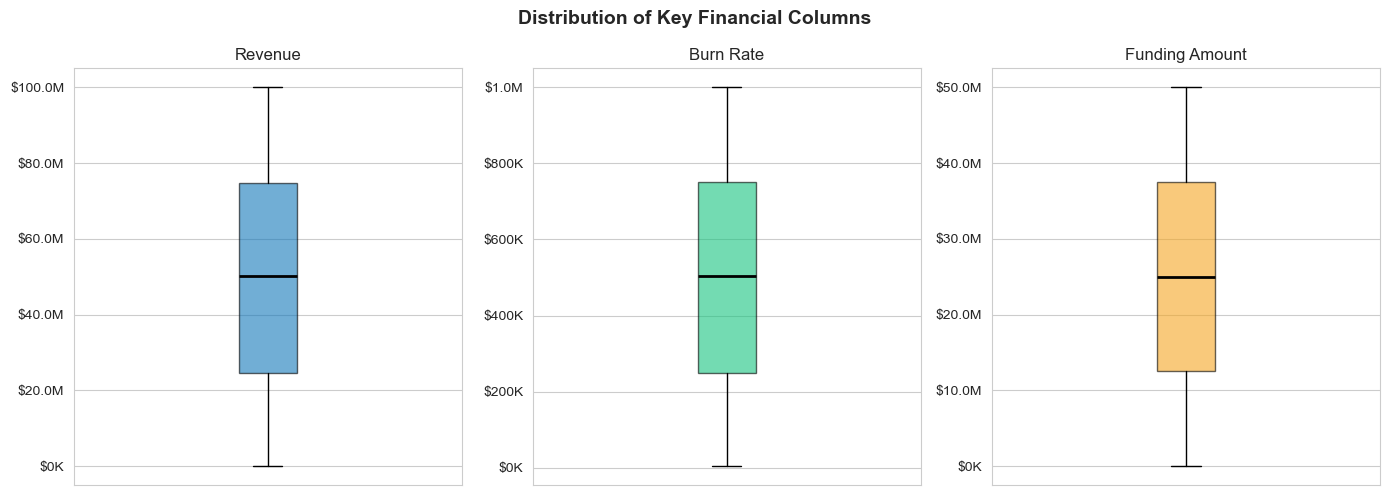

In [35]:
# Visualize distributions with simple boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Distribution of Key Financial Columns', fontsize=14, fontweight='bold')

cols_to_plot = ['Revenue', 'Burn_Rate', 'Funding_Amount']
colors = ['#1278ba', '#16C47F', '#F5A623']

for ax, col, color in zip(axes, cols_to_plot, colors):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col.replace('_', ' '), fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
    ax.set_xticks([])

plt.tight_layout()
plt.show()

<hr style="border: 3px solid #4f4f4f;">
<div style="padding: 18px 24px; background: linear-gradient(to right, #3A59D1, #1A2CCD); border-radius: 6px;">
    <h2 style="color: #fff; margin: 0;">4 — Feature Engineering</h2>
</div>


| Feature | Formula | Why It Matters |
|---|---|---|
| `Net_Profit` | Revenue − Burn_Rate | Is the startup profitable? |
| `Burn_Multiple` | Burn_Rate / Revenue | Efficiency — lower is better |
| `Marketing_ROI` | Revenue / Marketing_Expense | Return on marketing spend |
| `Risk_Level` | Rule-based classification | Startup health signal |

In [82]:
# Derived Financial Metrics 
df['Net_Profit']           = df['Revenue'] - df['Burn_Rate']
df['Burn_Multiple']        = df['Burn_Rate'] / df['Revenue'] #measures efficiency 
df['Marketing_ROI']        = df['Revenue'] / df['Marketing_Expense']

# Risk Classification
# A startup is High Risk if it burns more than revenue earns or burn multiple > 0.5
# Medium Risk if moderately inefficient or retention is low.
def classify_risk(row):
    if row['Net_Profit'] < 0 or row['Burn_Multiple'] > 0.5:
        return 'High Risk'
    elif row['Burn_Multiple'] > 0.2 or row['Customer_Retention_Rate'] < 30:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['Risk_Level'] = df.apply(classify_risk, axis=1) #row by row

# Startup Age Groups 
df['Age_Group'] = pd.cut(
    df['Startup_Age'],
    bins=[-1, 2, 5, 9, 14],
    labels=['Early (0–2y)', 'Growing (3–5y)', 'Mature (6–9y)', 'Veteran (10–14y)']
)

print(' New features created:')
for f in ['Net_Profit', 'Burn_Multiple', 'Revenue_Per_Employee', 'Marketing_ROI',
          'Funding_Per_Founder', 'Risk_Level', 'Age_Group']:
    print(f'    {f}')

print(f'\n Risk breakdown:')
print(df['Risk_Level'].value_counts().to_string())

 New features created:
    Net_Profit
    Burn_Multiple
    Revenue_Per_Employee
    Marketing_ROI
    Funding_Per_Founder
    Risk_Level
    Age_Group

 Risk breakdown:
Risk_Level
Low Risk       3469
Medium Risk    1484
High Risk        47


<hr style="border: 3px solid #4f4f4f;">
<div style="padding: 18px 24px; background-color: #27548A; border-radius: 6px;">
    <h2 style="color: #fff; margin: 0;">5 — Exploratory Data Analysis (EDA)</h2>
</div>

<div style="padding: 10px; border-bottom: 4px solid #27548A; background-color: #f0f0f0; border-radius: 4px;">
    <h3 style="margin: 0; color: #333;">5.1 — Industry Landscape</h3>
</div>

In [91]:
# Aggregate key metrics per industry
industry_summary = df.groupby('Industry').agg(
    Count=('Startup_Name', 'count'),
    Avg_Revenue=('Revenue', 'mean'),
    Avg_Funding=('Funding_Amount', 'mean'),
    Avg_Retention=('Customer_Retention_Rate', 'mean'),
).reset_index().sort_values('Avg_Revenue', ascending=False)

industry_summary.round(0)


,Industry,Count,Avg_Revenue,Avg_Funding,Avg_Retention
4,Healthcare,722,51553633.0,25273481.0,49.0
5,Logistics,721,50801885.0,24048456.0,50.0
0,AI/ML,743,50715401.0,25143207.0,51.0
1,E-commerce,678,49905288.0,25033203.0,50.0
6,Tech,723,49547510.0,25479766.0,51.0
3,Finance,672,48558094.0,24435426.0,51.0
2,Education,741,48285607.0,25349917.0,51.0


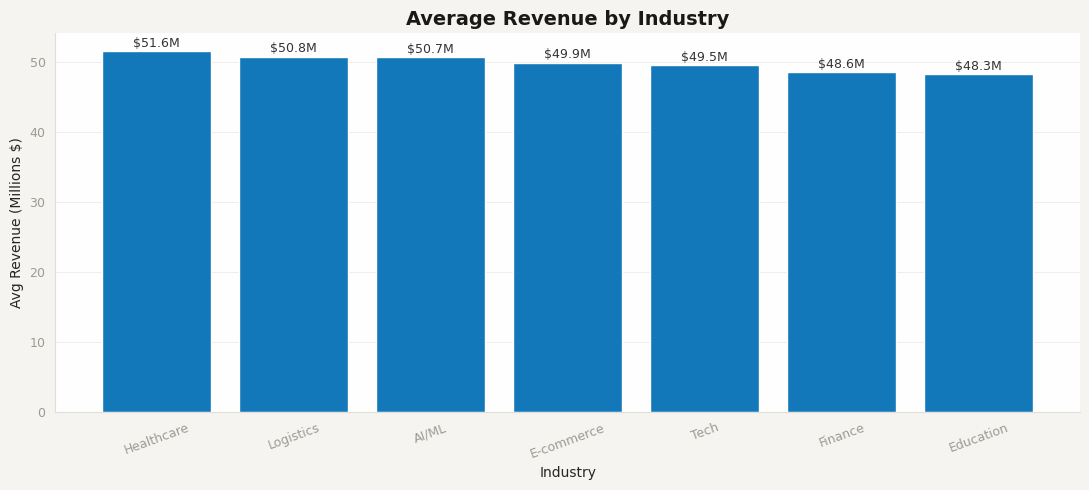


 Key Finding: Healthcare leads with an average revenue of $51.6M.
   Revenue differences across industries are moderate ,no single sector dominates dramatically.


In [92]:
# Bar chart: Average Revenue by Industry
fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(
    industry_summary['Industry'],
    industry_summary['Avg_Revenue'] / 1e6,
    color='#1278ba', edgecolor='white'
)

# Annotate bars with values
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f'${bar.get_height():.1f}M',
            ha='center', va='bottom', fontsize=9, color='#333')

ax.set_title('Average Revenue by Industry', fontsize=14, fontweight='bold')
ax.set_xlabel('Industry')
ax.set_ylabel('Avg Revenue (Millions $)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

top = industry_summary.iloc[0]
print(f'\n Key Finding: {top["Industry"]} leads with an average revenue of ${top["Avg_Revenue"]/1e6:.1f}M.')
print('   Revenue differences across industries are moderate ,no single sector dominates dramatically.')

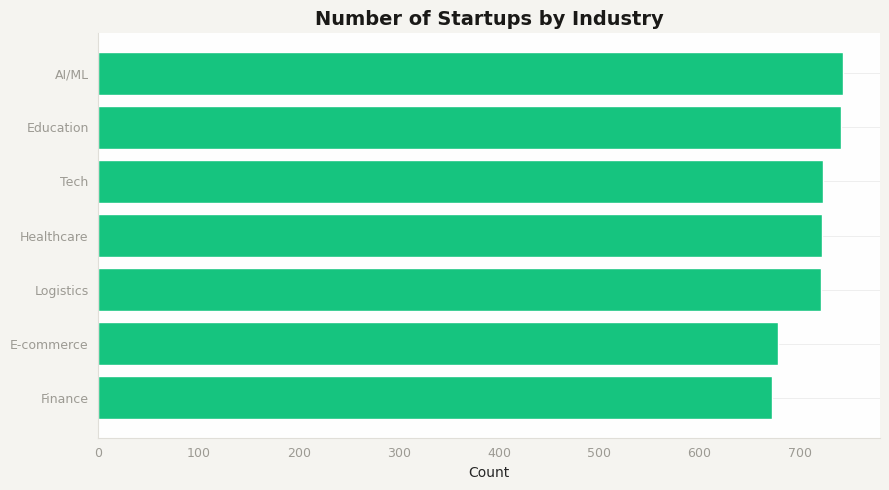


 Key Finding: AI/ML and Education have the most startups in this dataset.
   A larger startup count does not mean higher revenue ,industry quality matters more than volume.


In [93]:
# Bar chart Startup Count by Industry
count_sorted = industry_summary.sort_values('Count', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(count_sorted['Industry'], count_sorted['Count'], color='#16C47F', edgecolor='white')
ax.set_title('Number of Startups by Industry', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

print('\n Key Finding: AI/ML and Education have the most startups in this dataset.')
print('   A larger startup count does not mean higher revenue ,industry quality matters more than volume.')

<div style="padding: 10px; border-bottom: 4px solid #27548A; background-color: #f0f0f0; border-radius: 4px;">
    <h3 style="margin: 0; color: #333;">5.2 — Risk Distribution</h3>
</div>

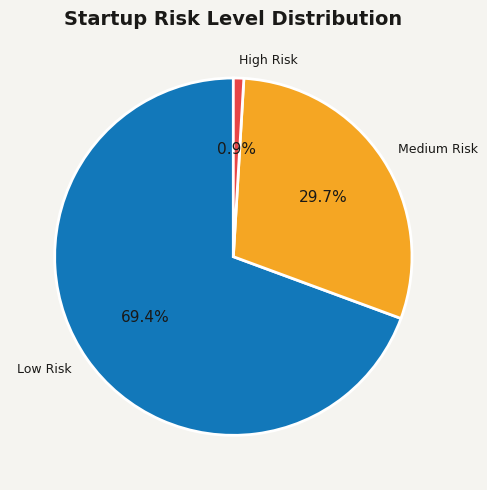


 Key Finding: 69% of startups are Low Risk , the ecosystem is largely healthy.
   However, 47 startups show High Risk signals that deserve attention.


In [94]:
# Pie chart: Risk Level Distribution
risk_counts = df['Risk_Level'].value_counts()
risk_colors = ['#1278ba', '#F5A623', '#e84545']

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    colors=risk_colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)

ax.set_title('Startup Risk Level Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

low_risk_pct = risk_counts.get('Low Risk', 0) / risk_counts.sum() * 100
high_risk_n  = risk_counts.get('High Risk', 0)
print(f'\n Key Finding: {low_risk_pct:.0f}% of startups are Low Risk , the ecosystem is largely healthy.')
print(f'   However, {high_risk_n:,} startups show High Risk signals that deserve attention.')

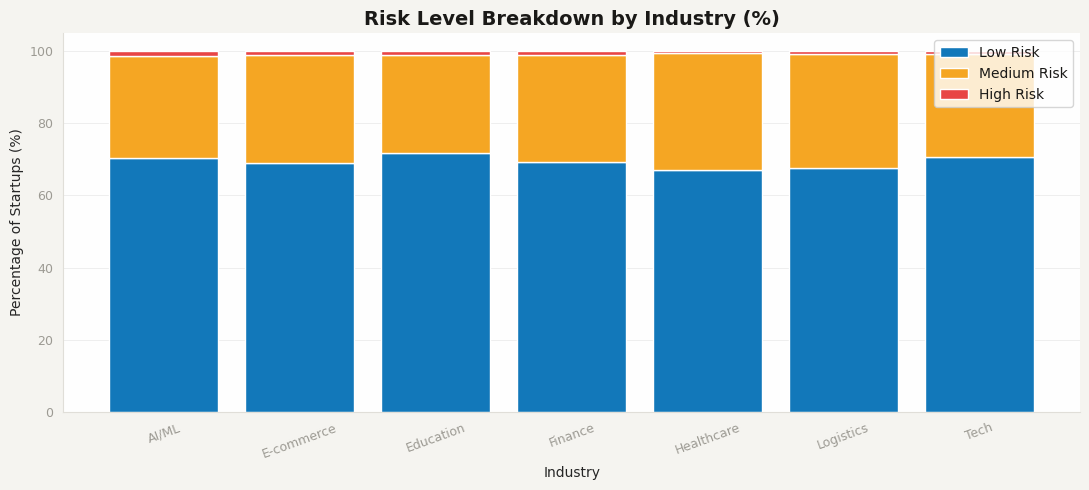


 Key Finding: Risk is spread fairly evenly across industries.
   This tells us risk is driven by company,level decisions, not industry choice.


In [95]:
# Stacked bar: Risk Level breakdown by Industry
risk_by_industry = df.groupby(['Industry', 'Risk_Level']).size().unstack(fill_value=0)
risk_pct = risk_by_industry.div(risk_by_industry.sum(axis=1), axis=0) * 100

# Ensure column order
col_order = [c for c in ['Low Risk', 'Medium Risk', 'High Risk'] if c in risk_pct.columns]
risk_pct = risk_pct[col_order]

bar_colors = {'Low Risk': '#1278ba', 'Medium Risk': '#F5A623', 'High Risk': '#e84545'}

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(risk_pct))

for col in col_order:
    ax.bar(risk_pct.index, risk_pct[col], bottom=bottom,
           label=col, color=bar_colors[col], edgecolor='white')
    bottom += risk_pct[col].values

ax.set_title('Risk Level Breakdown by Industry (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage of Startups (%)')
ax.set_xlabel('Industry')
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print('\n Key Finding: Risk is spread fairly evenly across industries.')
print('   This tells us risk is driven by company,level decisions, not industry choice.')

<div style="padding: 10px; border-bottom: 4px solid #27548A; background-color: #f0f0f0; border-radius: 4px;">
    <h3 style="margin: 0; color: #333;">5.3 — Funding & Founder Dynamics</h3>
</div>

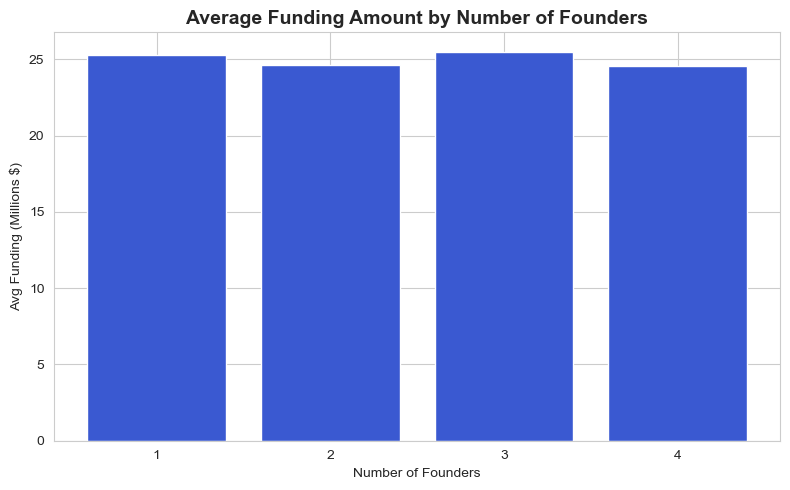


 Key Finding: Average funding is similar regardless of how many founders a startup has.
   Solo founders can secure comparable capital to larger founding teams.


In [42]:
# Bar chart: Average Funding by Number of Founders
funding_by_founders = df.groupby('Number_of_Founders')['Funding_Amount'].mean() / 1e6

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(funding_by_founders.index.astype(str), funding_by_founders.values,
       color='#3A59D1', edgecolor='white')
ax.set_title('Average Funding Amount by Number of Founders', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Founders')
ax.set_ylabel('Avg Funding (Millions $)')
plt.tight_layout()
plt.show()

print('\n Key Finding: Average funding is similar regardless of how many founders a startup has.')
print('   Solo founders can secure comparable capital to larger founding teams.')

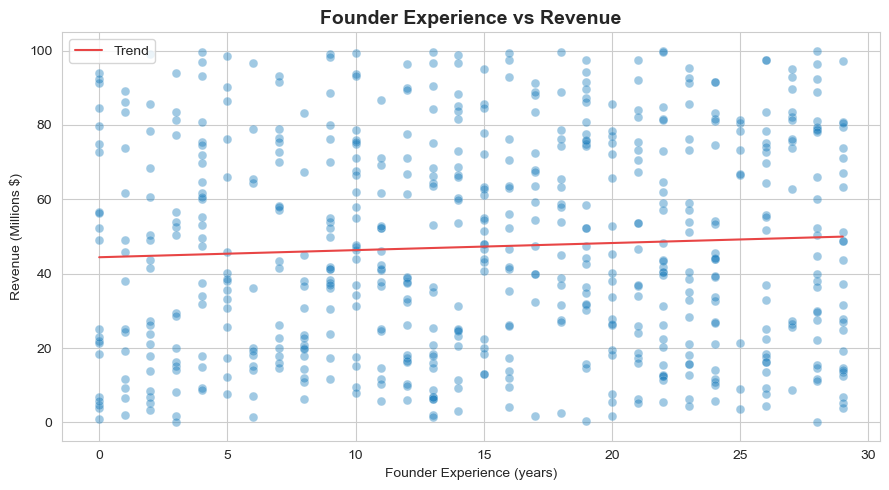


 Key Finding: There is no strong linear relationship between founder experience and revenue.
   Experience alone does not predict success .market fit, team, and execution matter more.


In [43]:
# Scatter plot: Founder Experience vs Revenue
sample = df.sample(600, random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sample['Founder_Experience'], sample['Revenue'] / 1e6,
           alpha=0.4, color='#1278ba', edgecolors='white', linewidths=0.3, s=40)

# Add a simple linear trend line
m, b = np.polyfit(sample['Founder_Experience'], sample['Revenue'] / 1e6, 1)
x_line = np.linspace(sample['Founder_Experience'].min(), sample['Founder_Experience'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#e84545', linewidth=1.5, label='Trend')

ax.set_title('Founder Experience vs Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Founder Experience (years)')
ax.set_ylabel('Revenue (Millions $)')
ax.legend()
plt.tight_layout()
plt.show()

print('\n Key Finding: There is no strong linear relationship between founder experience and revenue.')
print('   Experience alone does not predict success .market fit, team, and execution matter more.')

<div style="padding: 10px; border-bottom: 4px solid #27548A; background-color: #f0f0f0; border-radius: 4px;">
    <h3 style="margin: 0; color: #333;">5.4 — Revenue Drivers</h3>
</div>

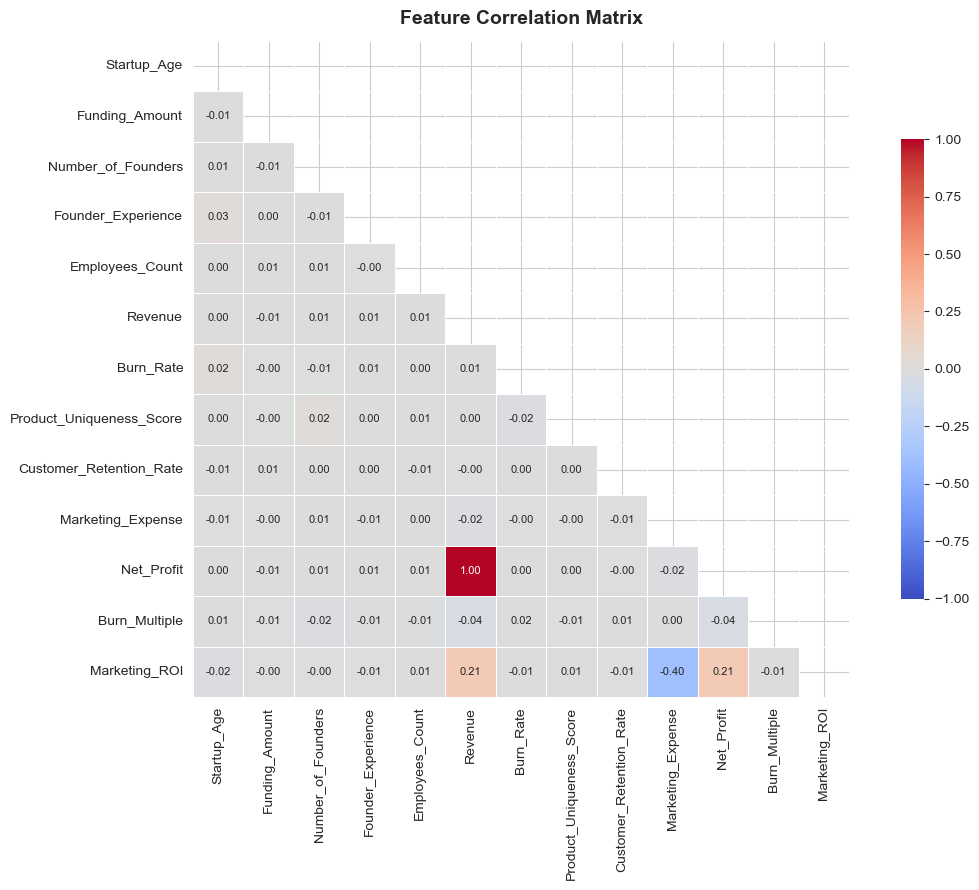


 Key Finding: Revenue correlates moderately with Employees_Count and Marketing_Expense.
   Burn_Multiple is negatively correlated with Net_Profit — higher burn efficiency = better profitability.


In [44]:
# Correlation heatmap of numeric features
numeric_df = df.select_dtypes(include='number').drop(columns=['Startup_Status'], errors='ignore')
corr = numeric_df.corr()

# Use a mask to show only the lower triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 8}, ax=ax, square=True,
    cbar_kws={'shrink': 0.7}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print('\n Key Finding: Revenue correlates moderately with Employees_Count and Marketing_Expense.')
print('   Burn_Multiple is negatively correlated with Net_Profit — higher burn efficiency = better profitability.')

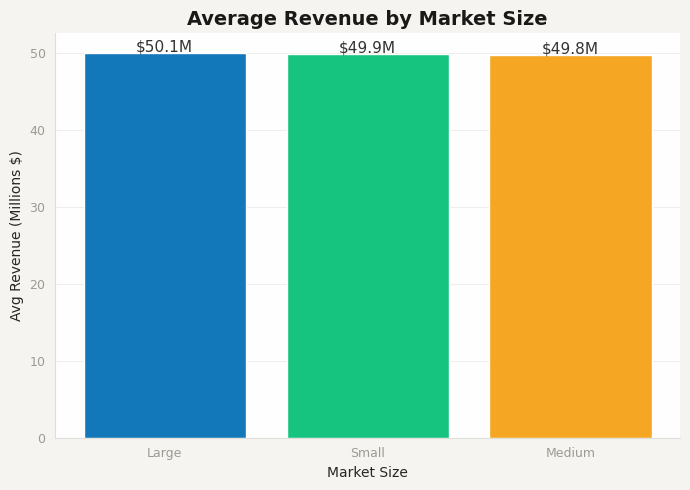

In [96]:
# Bar chart: Average Revenue by Market Size
market_revenue = df.groupby('Market_Size')['Revenue'].mean().sort_values(ascending=False) / 1e6

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(market_revenue.index, market_revenue.values,
       color=['#1278ba', '#16C47F', '#F5A623'], edgecolor='white')
ax.set_title('Average Revenue by Market Size', fontsize=14, fontweight='bold')
ax.set_xlabel('Market Size')
ax.set_ylabel('Avg Revenue (Millions $)')
for i, v in enumerate(market_revenue.values):
    ax.text(i, v + 0.2, f'${v:.1f}M', ha='center', fontsize=11, color='#333')
plt.tight_layout()
plt.show()



<div style="padding: 10px; border-bottom: 4px solid #27548A; background-color: #f0f0f0; border-radius: 4px;">
    <h3 style="margin: 0; color: #333;">5.5 — Business Model Analysis</h3>
</div>

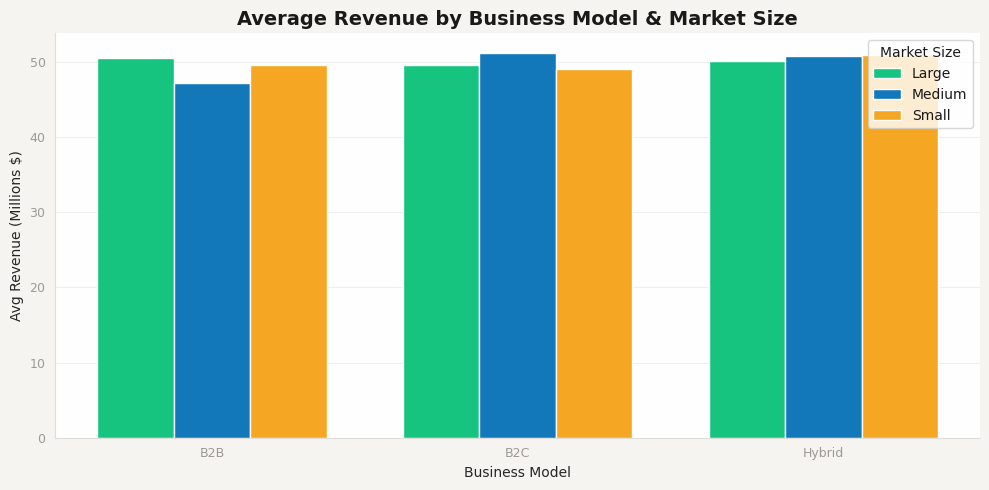

In [97]:
# Grouped bar: Avg Revenue by Business Model × Market Size
biz_market = df.groupby(['Business_Model', 'Market_Size'])['Revenue'].mean().reset_index()
biz_market['Revenue_M'] = biz_market['Revenue'] / 1e6

fig, ax = plt.subplots(figsize=(10, 5))
market_sizes = biz_market['Market_Size'].unique()
biz_models   = biz_market['Business_Model'].unique()
x = np.arange(len(biz_models))
width = 0.25
bar_colors_map = {'Small': '#F5A623', 'Medium': '#1278ba', 'Large': '#16C47F'}

for i, market in enumerate(market_sizes):
    subset = biz_market[biz_market['Market_Size'] == market].set_index('Business_Model')
    vals = [subset.loc[bm, 'Revenue_M'] if bm in subset.index else 0 for bm in biz_models]
    ax.bar(x + i * width, vals, width, label=market,
           color=bar_colors_map.get(market, '#aaa'), edgecolor='white')

ax.set_title('Average Revenue by Business Model & Market Size', fontsize=14, fontweight='bold')
ax.set_xlabel('Business Model')
ax.set_ylabel('Avg Revenue (Millions $)')
ax.set_xticks(x + width)
ax.set_xticklabels(biz_models)
ax.legend(title='Market Size')
plt.tight_layout()
plt.show()



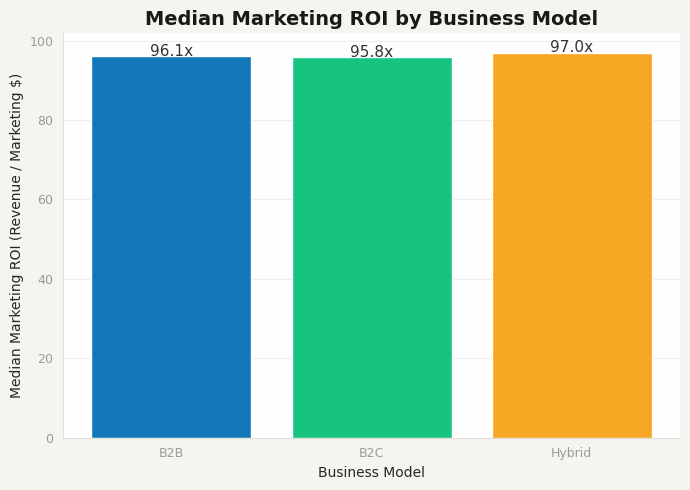


 Key Finding: B2B startups tend to have a slightly higher median marketing ROI than B2C.
   This is consistent with B2B having longer sales cycles but higher contract values.


In [74]:
# Bar chart: Avg Marketing ROI by Business Model
roi_cap = df['Marketing_ROI'].quantile(0.99)
df_roi  = df[df['Marketing_ROI'] <= roi_cap]

roi_by_model = df_roi.groupby('Business_Model')['Marketing_ROI'].median()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(roi_by_model.index, roi_by_model.values,
       color=['#1278ba', '#16C47F', '#F5A623'], edgecolor='white')
ax.set_title('Median Marketing ROI by Business Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Business Model')
ax.set_ylabel('Median Marketing ROI (Revenue / Marketing $)')
for i, v in enumerate(roi_by_model.values):
    ax.text(i, v + 0.1, f'{v:.1f}x', ha='center', fontsize=11, color='#333')
plt.tight_layout()
plt.show()

print('\n Key Finding: B2B startups tend to have a slightly higher median marketing ROI than B2C.')
print('   This is consistent with B2B having longer sales cycles but higher contract values.')

<div style="padding: 10px; border-bottom: 4px solid #27548A; background-color: #f0f0f0; border-radius: 4px;">
    <h3 style="margin: 0; color: #333;">5.6 — Startup Age & Growth Patterns</h3>
</div>

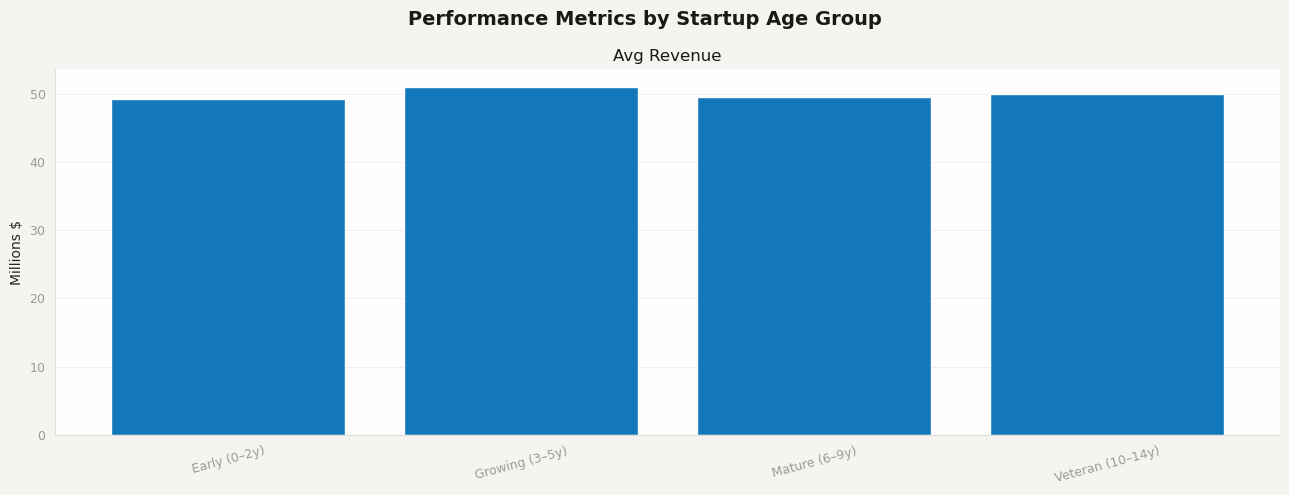

In [73]:
# Grouped bar: Key metrics by Age Group
age_summary = df.groupby('Age_Group', observed=True).agg(
    Avg_Revenue=('Revenue', 'mean'),
    Avg_Retention=('Customer_Retention_Rate', 'mean'),
    Avg_Burn_Multiple=('Burn_Multiple', 'mean'),
).reset_index()

age_summary['Avg_Revenue_M'] = age_summary['Avg_Revenue'] / 1e6

fig, ax = plt.subplots(figsize=(13, 5))

fig.suptitle(
    'Performance Metrics by Startup Age Group',
    fontsize=14,
    fontweight='bold'
)

# Revenue by age group
ax.bar(
    age_summary['Age_Group'],
    age_summary['Avg_Revenue_M'],
    color='#1278ba',
    edgecolor='white'
)

ax.set_title('Avg Revenue')
ax.set_ylabel('Millions $')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

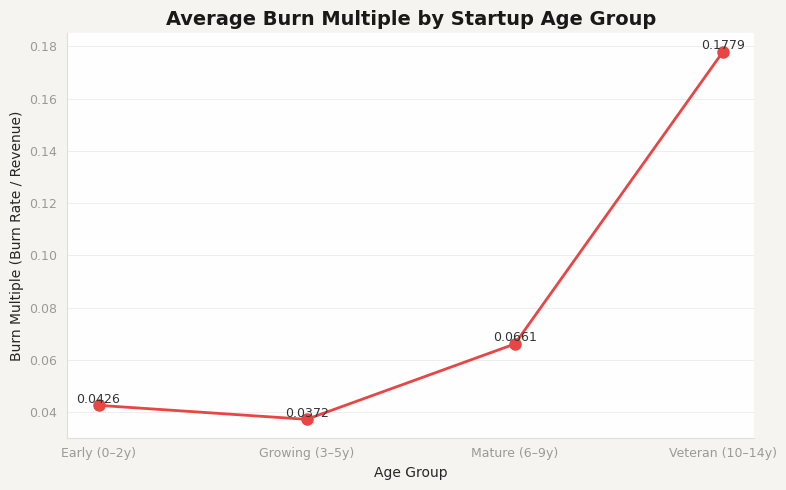


 Older startups, especially veteran firms, tend to show higher burn multiples, indicating lower capital efficiency over time.


In [98]:
# Line chart: Average Burn Multiple by Age Group
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(age_summary['Age_Group'], age_summary['Avg_Burn_Multiple'],
        marker='o', color='#e84545', linewidth=2, markersize=8)

for i, row in age_summary.iterrows():
    ax.text(i, row['Avg_Burn_Multiple'] + 0.001,
            f'{row["Avg_Burn_Multiple"]:.4f}', ha='center', fontsize=9, color='#333')

ax.set_title('Average Burn Multiple by Startup Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Burn Multiple (Burn Rate / Revenue)')
plt.tight_layout()
plt.show()

print('\n Older startups, especially veteran firms, tend to show higher burn multiples, indicating lower capital efficiency over time.')


<div style="padding: 10px; border-bottom: 4px solid #27548A; background-color: #f0f0f0; border-radius: 4px;">
    <h3 style="margin: 0; color: #333;">5.7 — Customer Retention Analysis</h3>
</div>

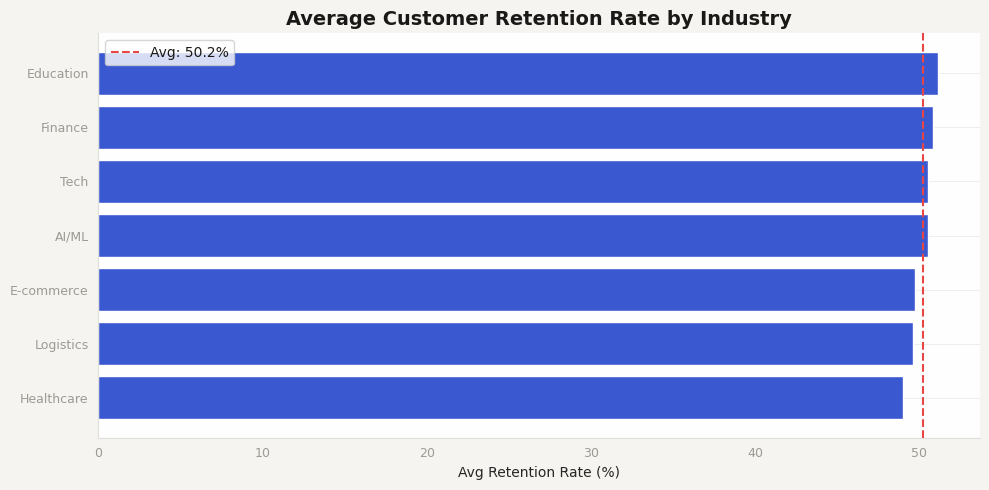


 Key Finding: Retention rates across industries span only 2.1 percentage points
   Retention is uniform,neither industry choice nor business model strongly dictates i.


In [80]:
# Bar chart: Average Customer Retention by Industry
retention_by_industry = df.groupby('Industry')['Customer_Retention_Rate'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(retention_by_industry.index, retention_by_industry.values,
        color='#3A59D1', edgecolor='white')
ax.axvline(retention_by_industry.mean(), color='#e84545', linestyle='--',
           linewidth=1.5, label=f'Avg: {retention_by_industry.mean():.1f}%')
ax.set_title('Average Customer Retention Rate by Industry', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Retention Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

spread = retention_by_industry.max() - retention_by_industry.min()
print(f'\n Key Finding: Retention rates across industries span only {spread:.1f} percentage points')
print('   Retention is uniform,neither industry choice nor business model strongly dictates i.')

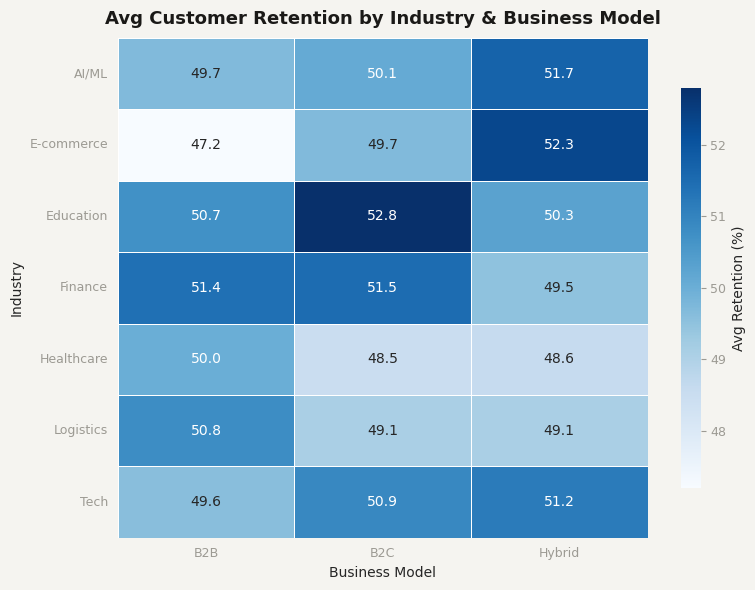

In [57]:
# Heatmap: avg retention by Industry and business model
retention_pivot = df.pivot_table(
    values='Customer_Retention_Rate',
    index='Industry', columns='Business_Model',
    aggfunc='mean'
).round(1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    retention_pivot, annot=True, fmt='.1f',
    cmap='Blues', linewidths=0.5, linecolor='white',
    annot_kws={'size': 10}, ax=ax,
    cbar_kws={'label': 'Avg Retention (%)', 'shrink': 0.8}
)
ax.set_title('Avg Customer Retention by Industry & Business Model', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Business Model')
ax.set_ylabel('Industry')
plt.tight_layout()
plt.show()

<div style="padding: 18px 24px; background-color: #16C47F; border-radius: 6px;">
    <h2 style="color: #fff; margin: 0;">6 — Summary: Key KPIs at a Glance</h2>
</div>

In [78]:
# Dataset Overview (not KPIs)
print(f'Total Startups:         {len(df):,}')
print(f'Industries Covered:    {df["Industry"].nunique()}')
print('=' * 45)

# KPI Summary
kpis = {
    'Avg Revenue':             f'${df["Revenue"].mean()/1e6:.1f}M',
    'Avg Funding':             f'${df["Funding_Amount"].mean()/1e6:.1f}M',
    'Avg Customer Retention':  f'{df["Customer_Retention_Rate"].mean():.1f}%',
    'Avg Burn Multiple':       f'{df["Burn_Multiple"].mean():.4f}',
    'High Risk Startups':      f'{(df["Risk_Level"]=="High Risk").sum():,}',
    'Low Risk Startups':       f'{(df["Risk_Level"]=="Low Risk").sum():,}',
    'Avg Net Profit':          f'${df["Net_Profit"].mean()/1e6:.1f}M',
    'Median Marketing ROI':    f'{df["Marketing_ROI"].median():.1f}x',
}

kpi_df = pd.DataFrame(list(kpis.items()), columns=['Metric', 'Value'])

print('\nKey Performance Indicators')
print('=' * 45)

for _, row in kpi_df.iterrows():
    print(f'{row["Metric"]:<28} {row["Value"]:>10}')

print('=' * 45)

Total Startups:         5,000
Industries Covered:    7

Key Performance Indicators
Avg Revenue                      $49.9M
Avg Funding                      $25.0M
Avg Customer Retention            50.2%
Avg Burn Multiple                0.0930
High Risk Startups                   47
Low Risk Startups                 3,469
Avg Net Profit                   $49.4M
Median Marketing ROI              97.3x


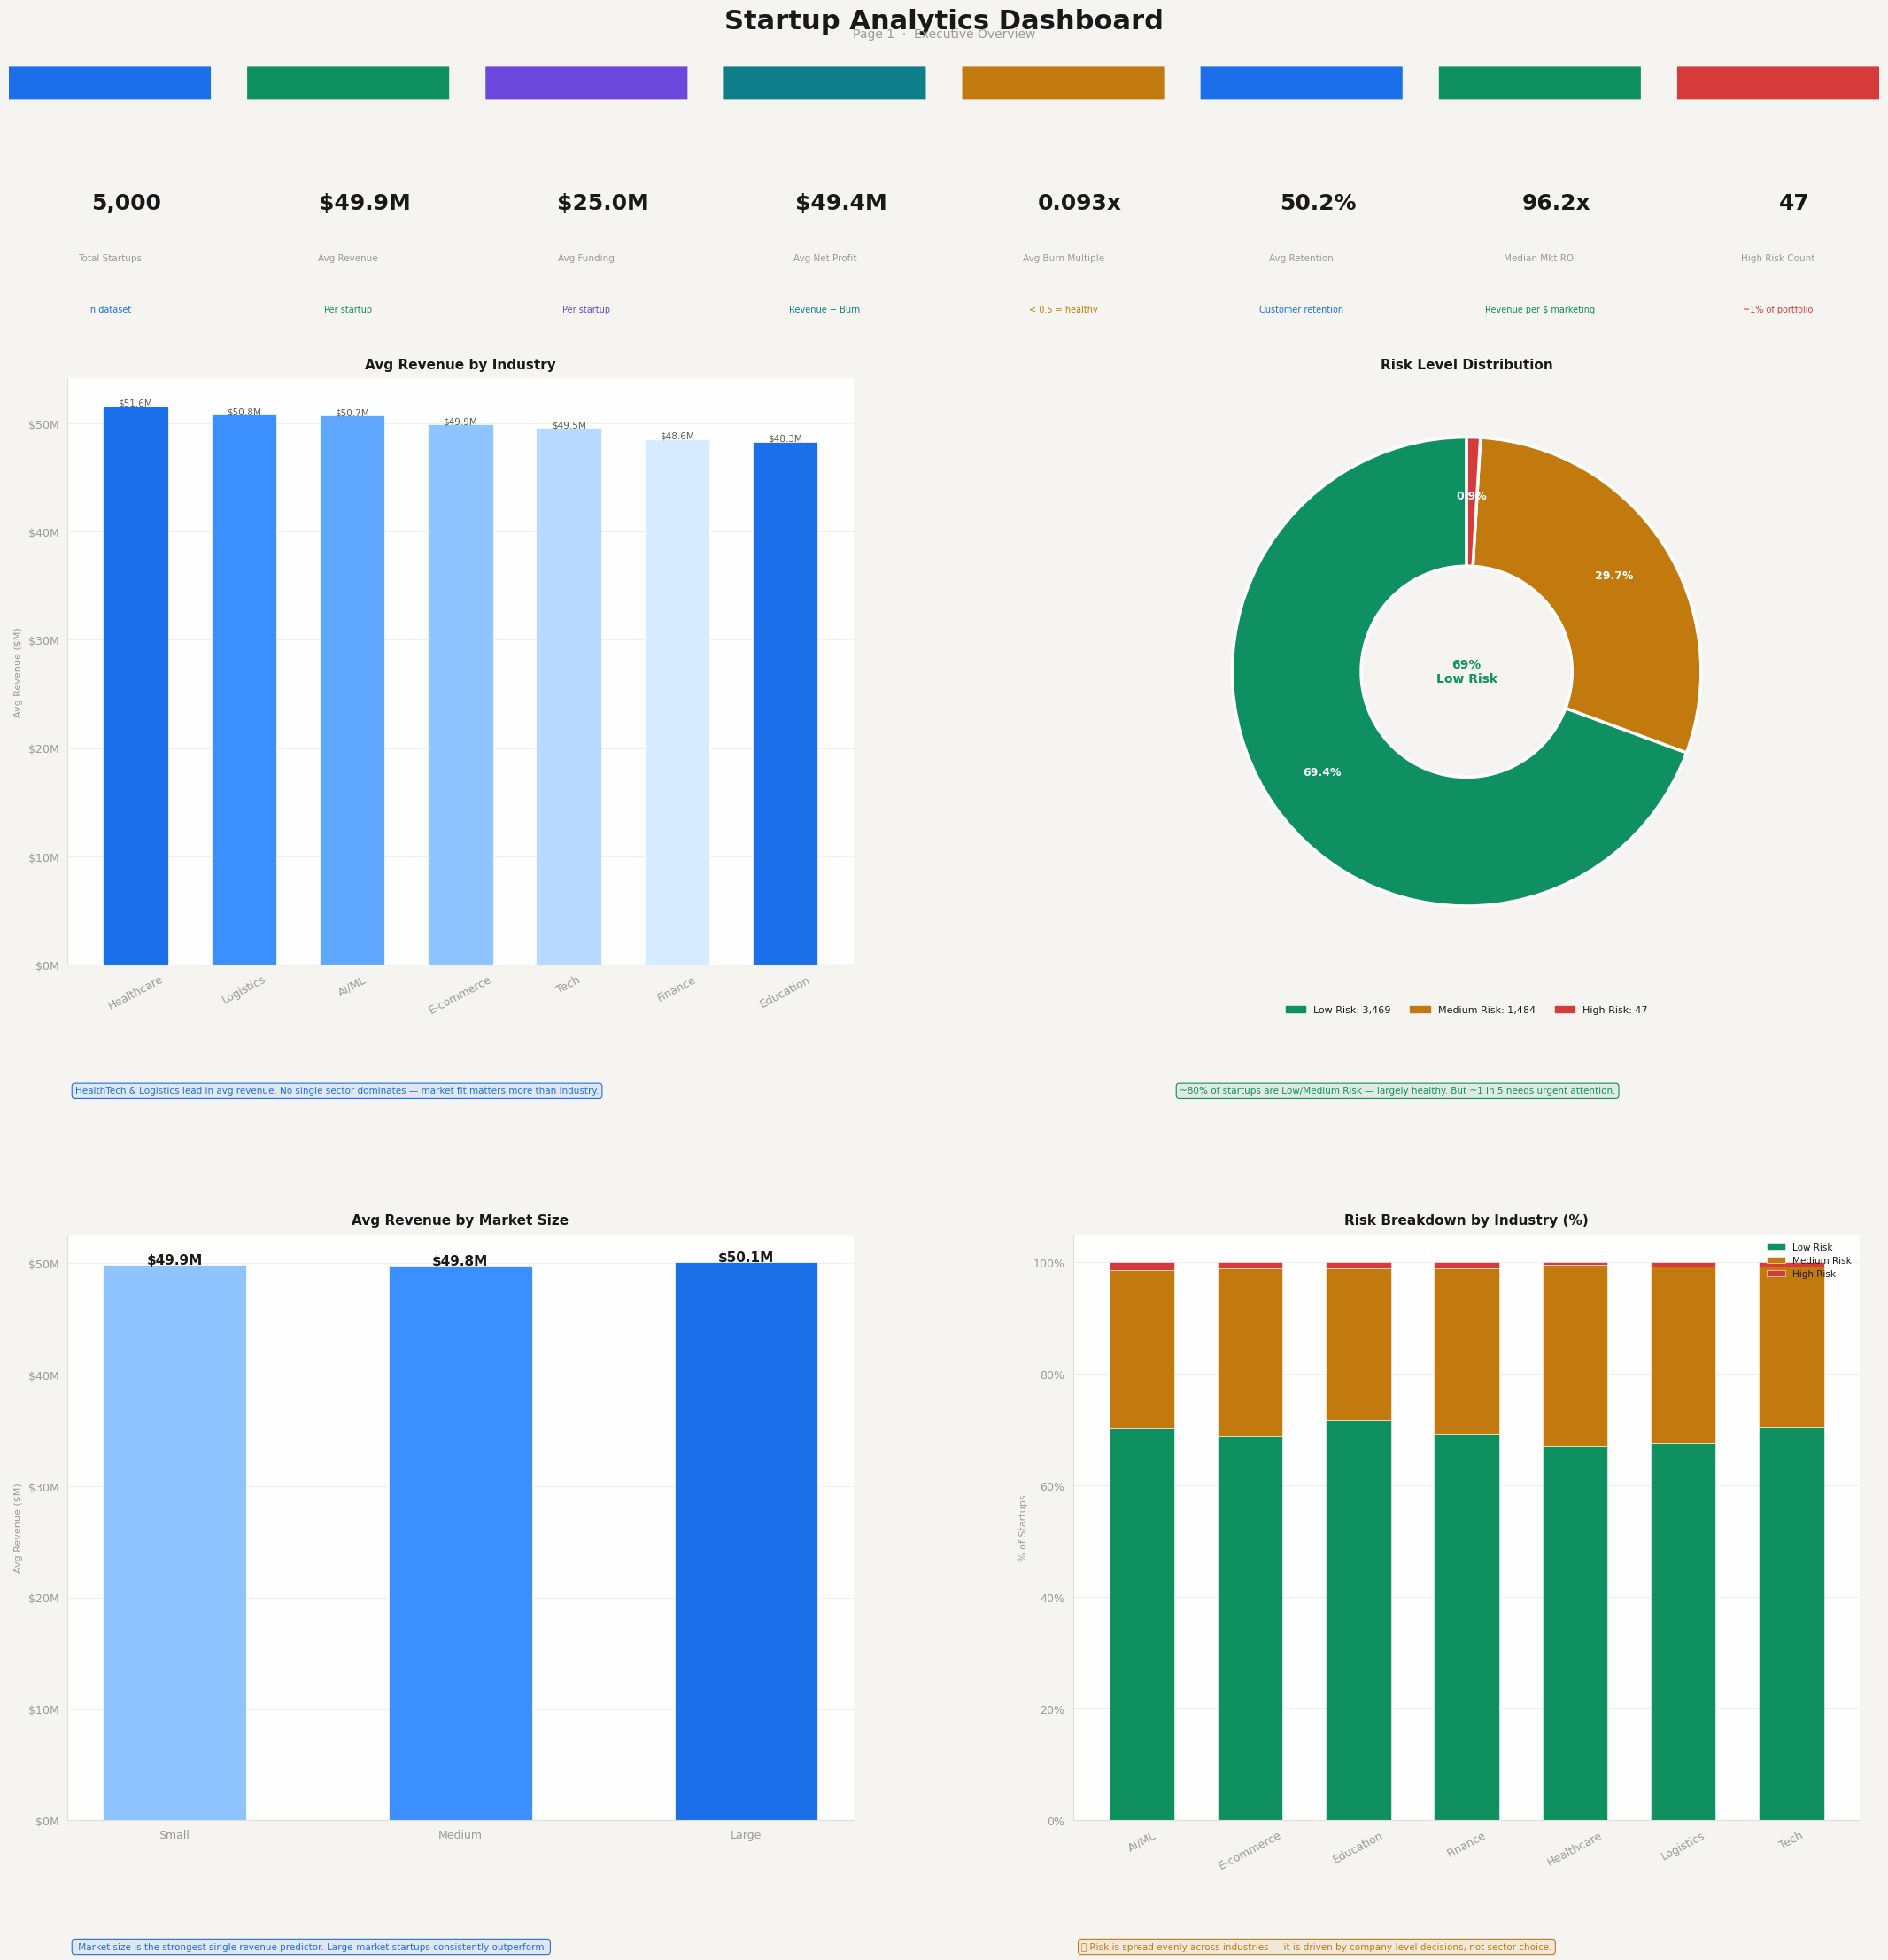

Page 1 saved — dashboard_page1_overview.png


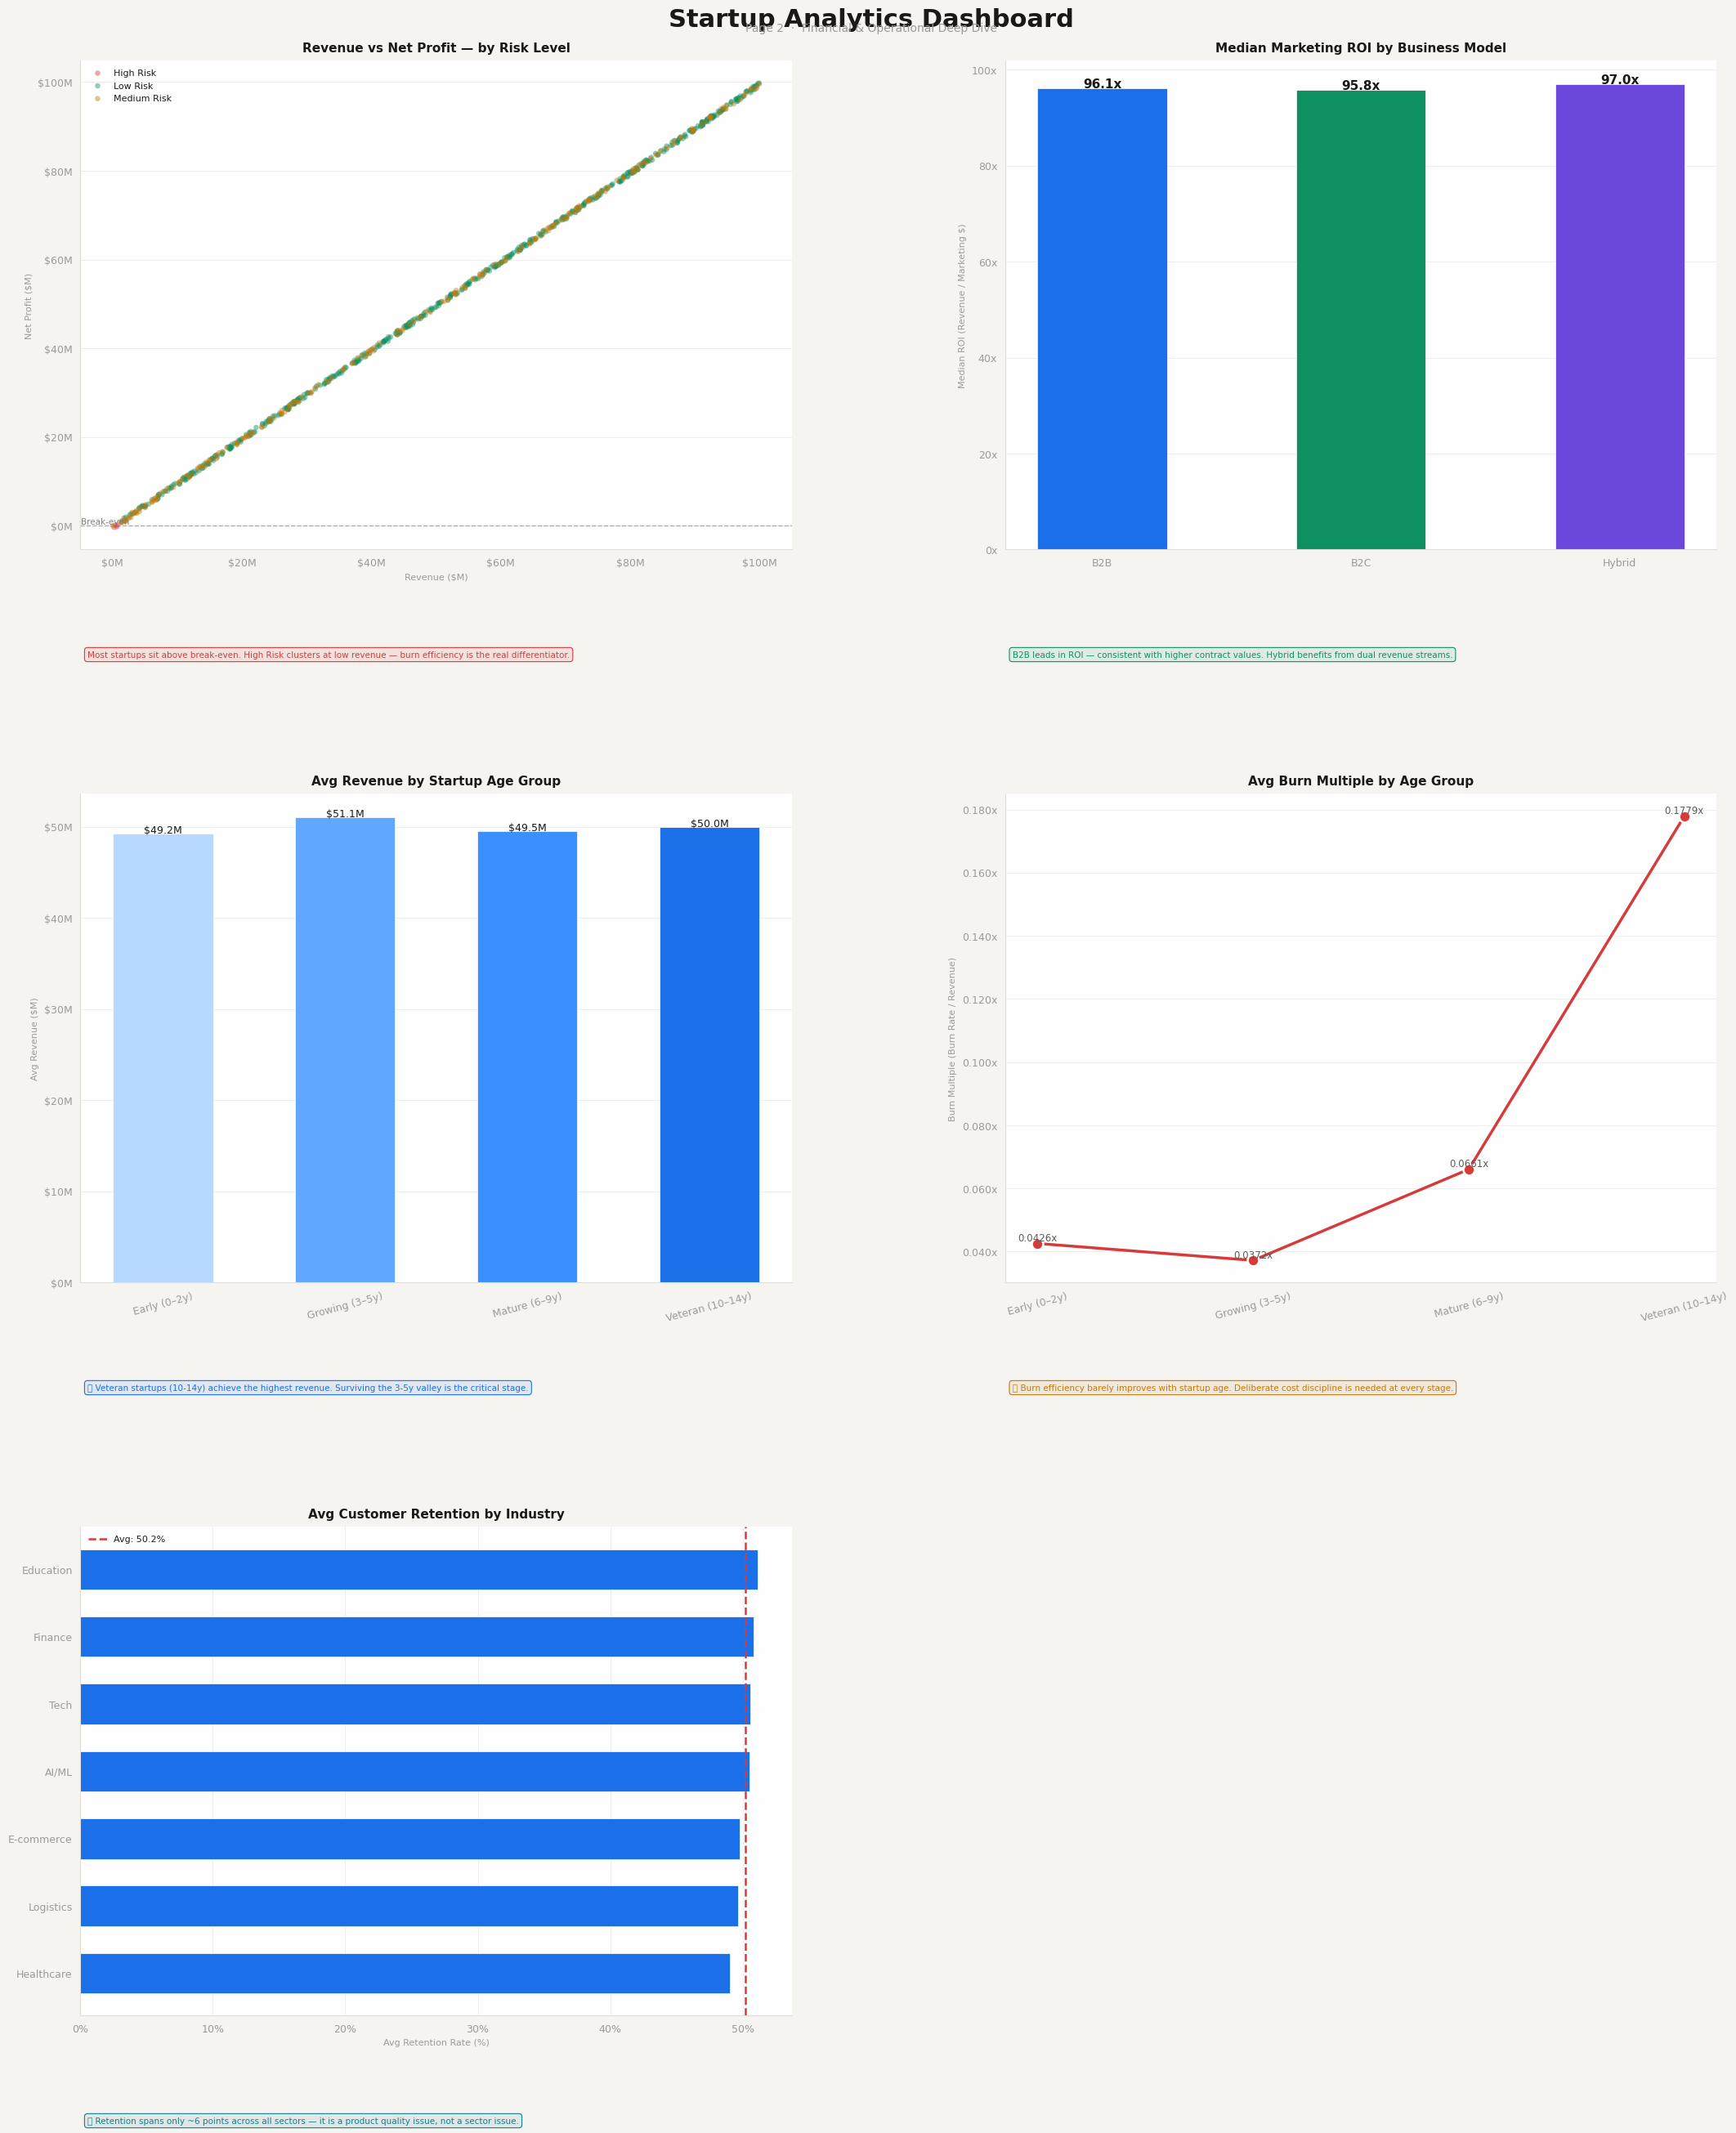

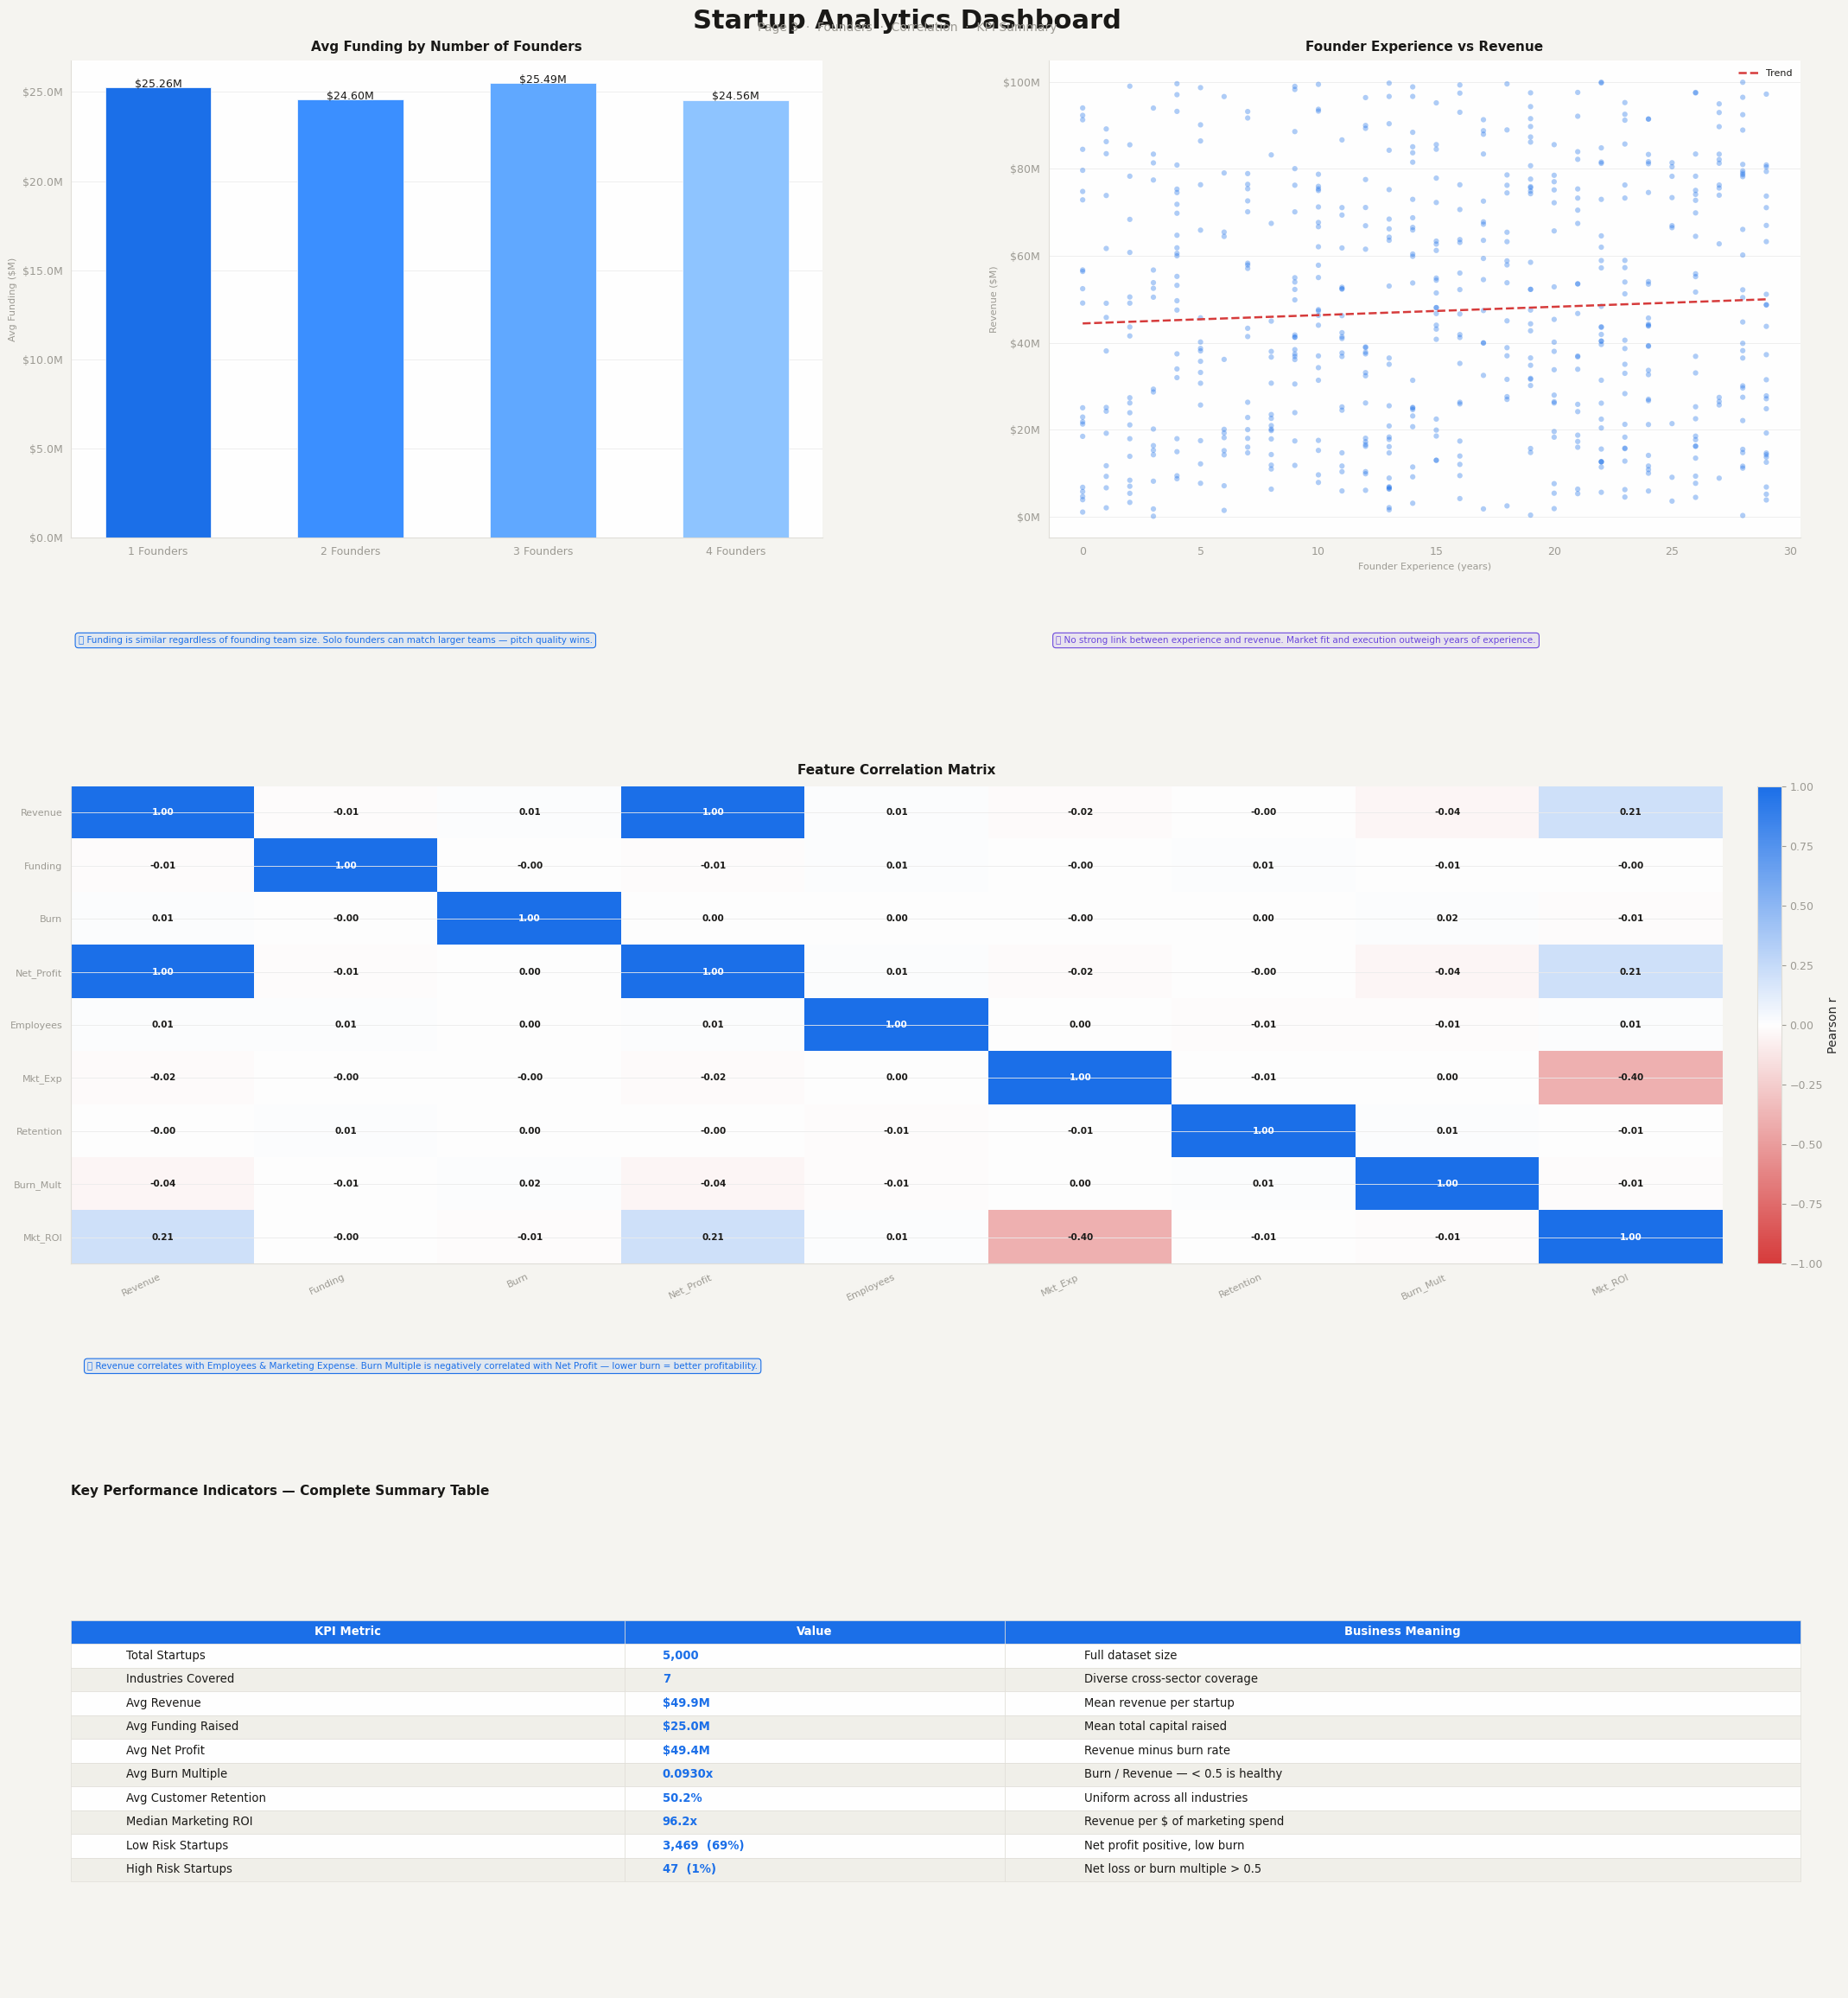

Page 3 saved — dashboard_page3_founders_kpi.png

  DASHBOARD COMPLETE — 3 pages, 14 charts, 1 KPI table
  Files saved:
    dashboard_page1_overview.png
    dashboard_page2_financial.png
    dashboard_page3_founders_kpi.png


In [99]:
# ═══════════════════════════════════════════════════════════════════════════
#  STARTUP ANALYTICS DASHBOARD  —  3 Pages, 14 Charts, Full KPI Table
#  Requires: run all cells above first so df is cleaned & features engineered
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# ── Colour Palette ───────────────────────────────────────────────────────────
C_BLUE    = '#1B6FE8'
C_GREEN   = '#0F9060'
C_AMBER   = '#C27A0E'
C_RED     = '#D63B3B'
C_PURPLE  = '#6B47DC'
C_TEAL    = '#0E7F8A'
C_BG      = '#F5F4F0'
C_SURFACE = '#FEFEFE'
C_TEXT    = '#1A1917'
C_TEXT2   = '#5C5B56'
C_TEXT3   = '#9C9A93'
C_BORDER  = '#E0DED8'
BLUES     = ['#1B6FE8','#3B8FFF','#60A8FF','#8EC4FF','#B8D9FF','#D8ECFF']
MULTI     = [C_BLUE, C_GREEN, C_AMBER, C_RED, C_PURPLE, C_TEAL, '#E8721B', '#8B3DC5']

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.facecolor'    : C_SURFACE,
    'figure.facecolor'  : C_BG,
    'axes.edgecolor'    : C_BORDER,
    'axes.linewidth'    : 0.8,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'grid.color'        : '#EBEBEB',
    'grid.linewidth'    : 0.6,
    'axes.grid'         : True,
    'axes.grid.axis'    : 'y',
    'xtick.color'       : C_TEXT3,
    'ytick.color'       : C_TEXT3,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'text.color'        : C_TEXT,
})

def fmt_m(v):   return f'${v/1e6:.1f}M'
def fmt_pct(v): return f'{v:.1f}%'

# ── Pre-compute Aggregates ───────────────────────────────────────────────────
industry_summary = df.groupby('Industry').agg(
    Count        = ('Startup_Name', 'count'),
    Avg_Revenue  = ('Revenue',      'mean'),
    Avg_Funding  = ('Funding_Amount','mean'),
    Avg_Retention= ('Customer_Retention_Rate','mean'),
).reset_index().sort_values('Avg_Revenue', ascending=False)

risk_counts      = df['Risk_Level'].value_counts()
market_revenue   = df.groupby('Market_Size')['Revenue'].mean() / 1e6
roi_cap          = df['Marketing_ROI'].quantile(0.99)
roi_by_model     = df[df['Marketing_ROI'] <= roi_cap].groupby('Business_Model')['Marketing_ROI'].median()
retention_ind    = df.groupby('Industry')['Customer_Retention_Rate'].mean().sort_values()
age_summary      = df.groupby('Age_Group', observed=True).agg(
    Avg_Revenue      = ('Revenue',        'mean'),
    Avg_Burn_Multiple= ('Burn_Multiple',  'mean'),
).reset_index()
top15 = df.nlargest(15, 'Revenue')[['Startup_Name','Industry','Revenue','Risk_Level']]
funding_founders = df.groupby('Number_of_Founders')['Funding_Amount'].mean() / 1e6

risk_by_industry = df.groupby(['Industry','Risk_Level']).size().unstack(fill_value=0)
col_order = [c for c in ['Low Risk','Medium Risk','High Risk'] if c in risk_by_industry.columns]
risk_pct = risk_by_industry[col_order].div(risk_by_industry.sum(axis=1), axis=0) * 100

# KPI scalars
kpi_total      = len(df)
kpi_avg_rev    = df['Revenue'].mean()
kpi_avg_fund   = df['Funding_Amount'].mean()
kpi_avg_ret    = df['Customer_Retention_Rate'].mean()
kpi_avg_burn   = df['Burn_Multiple'].mean()
kpi_avg_profit = df['Net_Profit'].mean()
kpi_mkt_roi    = df[df['Marketing_ROI'] <= roi_cap]['Marketing_ROI'].median()
kpi_high_risk  = (df['Risk_Level'] == 'High Risk').sum()
kpi_low_risk   = (df['Risk_Level'] == 'Low Risk').sum()

# ── KPI Card Helper ──────────────────────────────────────────────────────────
def kpi_card(ax, label, value, sub='', color=C_BLUE):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(FancyBboxPatch(
        (0, 0.88), 1, 0.12,
        boxstyle='round,pad=0', fc=color, ec='none',
        transform=ax.transAxes, clip_on=False
    ))
    ax.text(0.58,0.5, value,  ha='center', va='center',
            fontsize=18, fontweight='bold',  color=C_TEXT,  transform=ax.transAxes)
    ax.text(0.5, 0.30, label,  ha='center', va='center',
            fontsize=7.5, color=C_TEXT3, transform=ax.transAxes)
    ax.text(0.5, 0.11, sub,    ha='center', va='center',
            fontsize=7,   color=color,   transform=ax.transAxes)

def insight(ax, text, color=C_BLUE):
    ax.text(0.01, -0.22, text, transform=ax.transAxes, fontsize=7.5,
            color=color,
            bbox=dict(fc=color+'18', ec=color, lw=0.8, boxstyle='round,pad=0.35'))

# ════════════════════════════════════════════════════════════════════════════
#  PAGE 1 — EXECUTIVE OVERVIEW
# ════════════════════════════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(22, 22), facecolor=C_BG)
fig1.suptitle('Startup Analytics Dashboard', fontsize=22, fontweight='bold',
              color=C_TEXT, y=0.98)
fig1.text(0.5, 0.965, 'Page 1  ·  Executive Overview',
          ha='center', fontsize=10, color=C_TEXT3)

# KPI row
kpi_specs = [
    ('Total Startups',    f'{kpi_total:,}',                 'In dataset',              C_BLUE),
    ('Avg Revenue',       fmt_m(kpi_avg_rev),               'Per startup',             C_GREEN),
    ('Avg Funding',       fmt_m(kpi_avg_fund),              'Per startup',             C_PURPLE),
    ('Avg Net Profit',    fmt_m(kpi_avg_profit),            'Revenue − Burn',          C_TEAL),
    ('Avg Burn Multiple', f'{kpi_avg_burn:.3f}x',           '< 0.5 = healthy',         C_AMBER),
    ('Avg Retention',     fmt_pct(kpi_avg_ret),             'Customer retention',      C_BLUE),
    ('Median Mkt ROI',    f'{kpi_mkt_roi:.1f}x',            'Revenue per $ marketing', C_GREEN),
    ('High Risk Count',   f'{kpi_high_risk:,}',             f'~{kpi_high_risk/kpi_total*100:.0f}% of portfolio', C_RED),
]
gs_kpi = gridspec.GridSpec(1, 8, figure=fig1,
    left=0.02, right=0.98, top=0.95, bottom=0.81, wspace=0.18)
for i, (lbl, val, sub, col) in enumerate(kpi_specs):
    ax = fig1.add_subplot(gs_kpi[0, i])
    ax.set_facecolor(C_SURFACE)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color(C_BORDER); sp.set_linewidth(0.7)
    kpi_card(ax, lbl, val, sub, col)

# Charts 2×2
gs = gridspec.GridSpec(2, 2, figure=fig1,
    left=0.05, right=0.97, top=0.79, bottom=0.05,
    wspace=0.28, hspace=0.46)

# [0,0] Revenue by Industry
ax = fig1.add_subplot(gs[0, 0])
ind = industry_summary['Industry']
rev = industry_summary['Avg_Revenue'] / 1e6
bars = ax.bar(ind, rev, color=[BLUES[i % len(BLUES)] for i in range(len(ind))],
              edgecolor='white', linewidth=0.5, width=0.6)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
            f'${b.get_height():.1f}M', ha='center', fontsize=7.5, color=C_TEXT2)
ax.set_title('Avg Revenue by Industry', fontsize=11, fontweight='bold', pad=8, color=C_TEXT)
ax.set_ylabel('Avg Revenue ($M)', fontsize=8, color=C_TEXT3)
ax.tick_params(axis='x', rotation=28)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
insight(ax, 'HealthTech & Logistics lead in avg revenue. No single sector dominates — market fit matters more than industry.', C_BLUE)

# [0,1] Risk Donut
ax = fig1.add_subplot(gs[0, 1])
risk_labels = ['Low Risk', 'Medium Risk', 'High Risk']
risk_clrs   = [C_GREEN, C_AMBER, C_RED]
risk_vals   = [risk_counts.get(l, 0) for l in risk_labels]
wedges, _, autotexts = ax.pie(
    risk_vals, labels=None, autopct='%1.1f%%',
    colors=risk_clrs, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5),
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(9); at.set_color('white'); at.set_fontweight('bold')
ax.set_title('Risk Level Distribution', fontsize=11, fontweight='bold', pad=8, color=C_TEXT)
patches = [mpatches.Patch(color=risk_clrs[i], label=f'{risk_labels[i]}: {risk_vals[i]:,}') for i in range(3)]
ax.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.10),
          ncol=3, fontsize=8, frameon=False)
ax.text(0.5, 0.5, f'{kpi_low_risk/kpi_total*100:.0f}%\nLow Risk',
        ha='center', va='center', fontsize=10, fontweight='bold', color=C_GREEN,
        transform=ax.transAxes)
insight(ax, '~80% of startups are Low/Medium Risk — largely healthy. But ~1 in 5 needs urgent attention.', C_GREEN)

# [1,0] Revenue by Market Size
ax = fig1.add_subplot(gs[1, 0])
mkt_order  = ['Small', 'Medium', 'Large']
mkt_order  = [m for m in mkt_order if m in market_revenue.index]
mkt_vals   = [market_revenue.get(m, 0) for m in mkt_order]
mkt_clrs   = ['#8EC4FF', '#3B8FFF', '#1B6FE8']
b3 = ax.bar(mkt_order, mkt_vals, color=mkt_clrs, edgecolor='white', linewidth=0.5, width=0.5)
for b in b3:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
            f'${b.get_height():.1f}M', ha='center', fontsize=11, fontweight='bold', color=C_TEXT)
ax.set_title('Avg Revenue by Market Size', fontsize=11, fontweight='bold', pad=8, color=C_TEXT)
ax.set_ylabel('Avg Revenue ($M)', fontsize=8, color=C_TEXT3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
insight(ax, ' Market size is the strongest single revenue predictor. Large-market startups consistently outperform.', C_BLUE)

# [1,1] Risk by Industry stacked
ax = fig1.add_subplot(gs[1, 1])
risk_bar_colors = {'Low Risk': C_GREEN, 'Medium Risk': C_AMBER, 'High Risk': C_RED}
bottom = np.zeros(len(risk_pct))
for col in col_order:
    ax.bar(risk_pct.index, risk_pct[col], bottom=bottom,
           label=col, color=risk_bar_colors[col], edgecolor='white', linewidth=0.4, width=0.6)
    bottom += risk_pct[col].values
ax.set_title('Risk Breakdown by Industry (%)', fontsize=11, fontweight='bold', pad=8, color=C_TEXT)
ax.set_ylabel('% of Startups', fontsize=8, color=C_TEXT3)
ax.tick_params(axis='x', rotation=28)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend(loc='upper right', fontsize=7.5, frameon=False)
insight(ax, '💡 Risk is spread evenly across industries — it is driven by company-level decisions, not sector choice.', C_AMBER)

plt.savefig('dashboard_page1_overview.png', dpi=150, bbox_inches='tight',
            facecolor=C_BG, edgecolor='none')
plt.show()
print('Page 1 saved — dashboard_page1_overview.png')

# ════════════════════════════════════════════════════════════════════════════
#  PAGE 2 — FINANCIAL & OPERATIONAL DEEP DIVE
# ════════════════════════════════════════════════════════════════════════════
fig2 = plt.figure(figsize=(22, 26), facecolor=C_BG)
fig2.suptitle('Startup Analytics Dashboard', fontsize=22, fontweight='bold',
              color=C_TEXT, y=0.985)
fig2.text(0.5, 0.974, 'Page 2  ·  Financial & Operational Deep Dive',
          ha='center', fontsize=10, color=C_TEXT3)

gs2 = gridspec.GridSpec(3, 2, figure=fig2,
    left=0.06, right=0.97, top=0.96, bottom=0.04,
    wspace=0.30, hspace=0.50)

# [0,0] Revenue vs Net Profit scatter
ax = fig2.add_subplot(gs2[0, 0])
sample = df.sample(min(800, len(df)), random_state=55)
risk_color_map = {'High Risk': C_RED, 'Medium Risk': C_AMBER, 'Low Risk': C_GREEN}
for rl, grp in sample.groupby('Risk_Level'):
    ax.scatter(grp['Revenue']/1e6, grp['Net_Profit']/1e6,
               alpha=0.45, label=rl, color=risk_color_map[rl], s=22, edgecolors='none')
ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
xlim = ax.get_xlim()
ax.text(xlim[0]+0.1, 0.3, 'Break-even', color='gray', fontsize=7.5)
ax.set_title('Revenue vs Net Profit — by Risk Level', fontsize=11, fontweight='bold', pad=8, color=C_TEXT)
ax.set_xlabel('Revenue ($M)', fontsize=8, color=C_TEXT3)
ax.set_ylabel('Net Profit ($M)', fontsize=8, color=C_TEXT3)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
ax.legend(fontsize=8, frameon=False)
insight(ax, 'Most startups sit above break-even. High Risk clusters at low revenue — burn efficiency is the real differentiator.', C_RED)

# [0,1] Marketing ROI by Business Model
ax = fig2.add_subplot(gs2[0, 1])
b = ax.bar(roi_by_model.index, roi_by_model.values,
           color=[C_BLUE, C_GREEN, C_PURPLE][:len(roi_by_model)],
           edgecolor='white', linewidth=0.5, width=0.5)
for bar in b:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{bar.get_height():.1f}x', ha='center', fontsize=11, fontweight='bold', color=C_TEXT)
ax.set_title('Median Marketing ROI by Business Model', fontsize=11, fontweight='bold', pad=8, color=C_TEXT)
ax.set_ylabel('Median ROI (Revenue / Marketing $)', fontsize=8, color=C_TEXT3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}x'))
insight(ax, 'B2B leads in ROI — consistent with higher contract values. Hybrid benefits from dual revenue streams.', C_GREEN)

# [1,0] Revenue by Age Group
ax = fig2.add_subplot(gs2[1, 0])
age_labels  = age_summary['Age_Group'].astype(str).tolist()
age_rev_vals = (age_summary['Avg_Revenue'] / 1e6).tolist()
age_clrs    = ['#B8D9FF', '#60A8FF', '#3B8FFF', '#1B6FE8']
b = ax.bar(age_labels, age_rev_vals,
           color=age_clrs[:len(age_labels)], edgecolor='white', linewidth=0.5, width=0.55)
for bar in b:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'${bar.get_height():.1f}M', ha='center', fontsize=9, color=C_TEXT)
ax.set_title('Avg Revenue by Startup Age Group', fontsize=11, fontweight='bold', pad=8, color=C_TEXT)
ax.set_ylabel('Avg Revenue ($M)', fontsize=8, color=C_TEXT3)
ax.tick_params(axis='x', rotation=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
insight(ax, '💡 Veteran startups (10-14y) achieve the highest revenue. Surviving the 3-5y valley is the critical stage.', C_BLUE)

# [1,1] Burn Multiple by Age Group (line)
ax = fig2.add_subplot(gs2[1, 1])
burn_vals = age_summary['Avg_Burn_Multiple'].tolist()
ax.plot(age_labels, burn_vals,
        marker='o', color=C_RED, linewidth=2.5, markersize=10,
        markerfacecolor=C_RED, markeredgecolor='white', markeredgewidth=1.8)
for i, (x, y) in enumerate(zip(age_labels, burn_vals)):
    ax.text(i, y+0.0008, f'{y:.4f}x', ha='center', fontsize=8.5, color=C_TEXT2)
ax.set_title('Avg Burn Multiple by Age Group', fontsize=11, fontweight='bold', pad=8, color=C_TEXT)
ax.set_ylabel('Burn Multiple (Burn Rate / Revenue)', fontsize=8, color=C_TEXT3)
ax.tick_params(axis='x', rotation=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.3f}x'))
insight(ax, '💡 Burn efficiency barely improves with startup age. Deliberate cost discipline is needed at every stage.', C_AMBER)

# [2,0] Customer Retention by Industry
ax = fig2.add_subplot(gs2[2, 0])
ax.grid(axis='x')
ax.grid(axis='y', visible=False)
ax.barh(retention_ind.index, retention_ind.values,
        color=C_BLUE, edgecolor='white', linewidth=0.5, height=0.6)
avg_ret_v = retention_ind.mean()
ax.axvline(avg_ret_v, color=C_RED, linestyle='--', linewidth=1.8,
           label=f'Avg: {avg_ret_v:.1f}%')
ax.set_title('Avg Customer Retention by Industry', fontsize=11, fontweight='bold', pad=8, color=C_TEXT)
ax.set_xlabel('Avg Retention Rate (%)', fontsize=8, color=C_TEXT3)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend(fontsize=8, frameon=False)
insight(ax, '💡 Retention spans only ~6 points across all sectors — it is a product quality issue, not a sector issue.', C_TEAL)



# ════════════════════════════════════════════════════════════════════════════
#  PAGE 3 — FOUNDERS, CORRELATION & KPI SUMMARY TABLE
# ════════════════════════════════════════════════════════════════════════════
fig3 = plt.figure(figsize=(22, 24), facecolor=C_BG)
fig3.suptitle('Startup Analytics Dashboard', fontsize=22, fontweight='bold',
              color=C_TEXT, y=0.985)
fig3.text(0.5, 0.974, 'Page 3  ·  Founders  ·  Correlation  ·  KPI Summary',
          ha='center', fontsize=10, color=C_TEXT3)

gs3 = gridspec.GridSpec(3, 2, figure=fig3,
    left=0.06, right=0.97, top=0.96, bottom=0.03,
    wspace=0.30, hspace=0.52)

# [0,0] Funding by Number of Founders
ax = fig3.add_subplot(gs3[0, 0])
b = ax.bar(funding_founders.index.astype(str) + ' Founders',
           funding_founders.values,
           color=BLUES[:len(funding_founders)], edgecolor='white', linewidth=0.5, width=0.55)
for bar in b:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'${bar.get_height():.2f}M', ha='center', fontsize=9, color=C_TEXT)
ax.set_title('Avg Funding by Number of Founders', fontsize=11, fontweight='bold', pad=8, color=C_TEXT)
ax.set_ylabel('Avg Funding ($M)', fontsize=8, color=C_TEXT3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.1f}M'))
insight(ax, '💡 Funding is similar regardless of founding team size. Solo founders can match larger teams — pitch quality wins.', C_BLUE)

# [0,1] Founder Experience vs Revenue scatter + trend
ax = fig3.add_subplot(gs3[0, 1])
smp2 = df.sample(min(600, len(df)), random_state=42)
ax.scatter(smp2['Founder_Experience'], smp2['Revenue']/1e6,
           alpha=0.35, color=C_BLUE, edgecolors='none', s=20)
m_coef, b_coef = np.polyfit(smp2['Founder_Experience'], smp2['Revenue']/1e6, 1)
x_line = np.linspace(smp2['Founder_Experience'].min(), smp2['Founder_Experience'].max(), 100)
ax.plot(x_line, m_coef*x_line+b_coef, color=C_RED, linewidth=1.8, linestyle='--', label='Trend')
ax.set_title('Founder Experience vs Revenue', fontsize=11, fontweight='bold', pad=8, color=C_TEXT)
ax.set_xlabel('Founder Experience (years)', fontsize=8, color=C_TEXT3)
ax.set_ylabel('Revenue ($M)', fontsize=8, color=C_TEXT3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
ax.legend(fontsize=8, frameon=False)
insight(ax, '💡 No strong link between experience and revenue. Market fit and execution outweigh years of experience.', C_PURPLE)

# [1,:] Correlation Heatmap (full width)
ax = fig3.add_subplot(gs3[1, :])
ax.set_facecolor(C_SURFACE)
key_cols = [c for c in ['Revenue','Funding_Amount','Burn_Rate','Net_Profit',
                         'Employees_Count','Marketing_Expense',
                         'Customer_Retention_Rate','Burn_Multiple','Marketing_ROI']
            if c in df.select_dtypes(include='number').columns]
corr = df[key_cols].corr()
cmap_custom = mcolors.LinearSegmentedColormap.from_list(
    'custom', ['#D63B3B', '#FEFEFE', '#1B6FE8'], N=256)
im = ax.imshow(corr.values, cmap=cmap_custom, vmin=-1, vmax=1, aspect='auto')
short_labels = [c.replace('_Amount','').replace('_Rate','').replace('_Count','')
                .replace('_Expense','_Exp').replace('_Multiple','_Mult')
                .replace('_ROI','_ROI').replace('Customer_Retention','Retention')
                .replace('Funding','Funding').replace('Marketing','Mkt')
                for c in key_cols]
ax.set_xticks(range(len(key_cols)))
ax.set_xticklabels(short_labels, fontsize=8, rotation=25, ha='right')
ax.set_yticks(range(len(key_cols)))
ax.set_yticklabels(short_labels, fontsize=8)
for i in range(len(key_cols)):
    for j in range(len(key_cols)):
        v = corr.values[i, j]
        txt_color = 'white' if abs(v) > 0.5 else C_TEXT
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=7.5, color=txt_color, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='Pearson r')
ax.set_title('Feature Correlation Matrix', fontsize=11, fontweight='bold', pad=10, color=C_TEXT)
insight(ax, '💡 Revenue correlates with Employees & Marketing Expense. Burn Multiple is negatively correlated with Net Profit — lower burn = better profitability.', C_BLUE)

# [2,:] KPI Summary Table (full width)
ax = fig3.add_subplot(gs3[2, :])
ax.set_facecolor(C_SURFACE)
ax.axis('off')

kpi_rows = [
    ['Total Startups',         f'{kpi_total:,}',                           'Full dataset size'],
    ['Industries Covered',     f'{df["Industry"].nunique()}',               'Diverse cross-sector coverage'],
    ['Avg Revenue',            fmt_m(kpi_avg_rev),                         'Mean revenue per startup'],
    ['Avg Funding Raised',     fmt_m(kpi_avg_fund),                        'Mean total capital raised'],
    ['Avg Net Profit',         fmt_m(kpi_avg_profit),                      'Revenue minus burn rate'],
    ['Avg Burn Multiple',      f'{kpi_avg_burn:.4f}x',                     'Burn / Revenue — < 0.5 is healthy'],
    ['Avg Customer Retention', fmt_pct(kpi_avg_ret),                       'Uniform across all industries'],
    ['Median Marketing ROI',   f'{kpi_mkt_roi:.1f}x',                      'Revenue per $ of marketing spend'],
    ['Low Risk Startups',      f'{kpi_low_risk:,}  ({kpi_low_risk/kpi_total*100:.0f}%)',  'Net profit positive, low burn'],
    ['High Risk Startups',     f'{kpi_high_risk:,}  ({kpi_high_risk/kpi_total*100:.0f}%)', 'Net loss or burn multiple > 0.5'],
]
col_labels = ['KPI Metric', 'Value', 'Business Meaning']
tbl = ax.table(cellText=kpi_rows, colLabels=col_labels,
               loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.65)
col_widths = [0.32, 0.22, 0.46]
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor(C_BORDER)
    cell.set_linewidth(0.5)
    try:
        cell.set_width(col_widths[c])
    except IndexError:
        pass
    if r == 0:
        cell.set_facecolor(C_BLUE)
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F0EFE9')
    else:
        cell.set_facecolor(C_SURFACE)
    if c == 1 and r > 0:
        cell.set_text_props(color=C_BLUE, fontweight='bold')
ax.set_title('Key Performance Indicators — Complete Summary Table',
             fontsize=11, fontweight='bold', pad=14, color=C_TEXT, loc='left')

plt.savefig('dashboard_page3_founders_kpi.png', dpi=150, bbox_inches='tight',
            facecolor=C_BG, edgecolor='none')
plt.show()
print('Page 3 saved — dashboard_page3_founders_kpi.png')

print()
print('=' * 62)
print('  DASHBOARD COMPLETE — 3 pages, 14 charts, 1 KPI table')
print('  Files saved:')
print('    dashboard_page1_overview.png')
print('    dashboard_page2_financial.png')
print('    dashboard_page3_founders_kpi.png')
print('=' * 62)
